# Low-Dimensional Cross-Scale Supplement

This notebook runs low12 as an independent supplementary experiment over twelve cumulative-energy observations below 0.5. It reuses the fixed full-SVD spectrum and deterministic full-PCA matrices from the main study, writes every new result under an isolated low12 namespace, and demonstrates each pipeline component through a self-contained example.

<a id="navigation-index"></a>
## Navigation Index

Use this index to jump directly to each analysis stage. Every entry summarizes the purpose of the corresponding section.

- [Part I: Spectrum Analysis](#part-i-spectrum-analysis) — Establish the fixed spectral inputs and the independent low12 scale contract.
  - [1.1 Fixed Spectrum Loading](#section-1-1) — Load and validate each model's fixed full-SVD spectrum and main-study scale provenance.
  - [1.2 Low12 Scale Selection](#section-1-2) — Select twelve dimensions from cumulative-energy thresholds below 0.5 and persist the mappings.
  - [1.3 Full-PCA Prefix Access](#section-1-3) — Confirm that every low12 representation is an exact prefix view of the fixed full-PCA matrix.
  - [Part I Output Contract](#part-i-output-contract) — Summarize the persistent artifacts and the no-recomputation guarantees produced by Part I.
- [Part II: Cross-Scale Analysis](#part-ii-cross-scale-analysis) — Build and analyze the deterministic low12 baseline across all models and scales.
  - [2.1 Full-PCA HDBSCAN Baseline](#section-2-1) — Produce the 36 baseline HDBSCAN partitions from deterministic full-PCA prefixes.
  - [2.2 Baseline Orthographic Similarity](#section-2-2) — Compute partition-level Orthographic Similarity and its uncertainty for every baseline partition.
  - [2.3 Baseline Multi-Script Entropy](#section-2-3) — Compute raw and normalized Multi-Script Entropy observations for every baseline partition.
  - [2.4 Baseline Cross-Scale Curves](#section-2-4) — Plot O-S and raw MS-E together with the visual contract used by `0_tool_fig.ipynb`.
  - [2.5 Low12 Cluster Statistics](#section-2-5) — Summarize cluster counts and cluster-size distributions across the twelve dimensions.
- [Part III: Robustness Analyses](#part-iii-robustness-analyses) — Test whether the baseline trends remain stable under representation, clustering, and token controls.
  - [3.1.1 Cross-Seed Stability](#section-3-1-1) — Construct randomized-PCA representations across eight seeds for every model and scale.
    - [3.1.1.2 Random-PCA HDBSCAN](#section-3-1-1-2) — Cluster every randomized-PCA representation with the baseline HDBSCAN configuration.
    - [3.1.1.3 Random-PCA Orthographic Similarity](#section-3-1-1-3) — Compute O-S for all randomized-PCA partitions.
    - [3.1.1.4 Random-PCA Multi-Script Entropy](#section-3-1-1-4) — Compute MS-E observations for all randomized-PCA partitions.
    - [3.1.1.5 Baseline-vs-Random Statistics](#section-3-1-1-5) — Evaluate Spearman correlation, MAE, and directional R² for O-S and raw MS-E, then aggregate seeds.
    - [3.1.1.6 Cross-Seed Supplementary Curves](#section-3-1-1-6) — Compare the deterministic baseline with randomized-PCA means and sample-SD bands.
  - [3.1.2 HDBSCAN Parameter Stability](#section-3-1-2) — Generate partitions for six explicit HDBSCAN parameter perturbations.
    - [3.1.2.2 Configuration Orthographic Similarity](#section-3-1-2-2) — Compute O-S for every HDBSCAN configuration.
    - [3.1.2.3 Configuration Multi-Script Entropy](#section-3-1-2-3) — Compute MS-E for every HDBSCAN configuration.
    - [3.1.2.4 Baseline-vs-Configuration Statistics](#section-3-1-2-4) — Evaluate Spearman correlation, MAE, and directional R² for O-S and raw MS-E.
    - [3.1.2.5 HDBSCAN Supplementary Curves](#section-3-1-2-5) — Compare the baseline with all six configuration curves.
  - [3.2 Permutation Controls](#section-3-2) — Create global token-permutation partitions across ten deterministic seeds.
    - [3.2.1.2 Token-Permutation Orthographic Similarity](#section-3-2-1-2) — Compute O-S for every global token-permutation partition.
    - [3.2.1.3 Token-Permutation Multi-Script Entropy](#section-3-2-1-3) — Compute MS-E for every global token-permutation partition.
    - [3.2.1.4 Baseline-vs-Permutation Statistics](#section-3-2-1-4) — Evaluate Spearman correlation, MAE, and directional R² for O-S and raw MS-E, then aggregate seeds.
    - [3.2.1.5 Token-Permutation Supplementary Curves](#section-3-2-1-5) — Compare the baseline with token-permutation means and sample-SD bands.
  - [3.2.2 Length-Bucket Permutation](#section-3-2-2) — Permute tokens within length buckets while preserving the control's structural constraints.
    - [3.2.2.2 Length-Bucket Orthographic Similarity](#section-3-2-2-2) — Compute O-S for every length-bucket partition.
    - [3.2.2.3 O-S Agreement and Seed Aggregation](#section-3-2-2-3) — Evaluate Spearman correlation, MAE, and directional R² for O-S and aggregate seeds.
    - [3.2.2.4 O-S Supplementary Curves](#section-3-2-2-4) — Compare the baseline with length-bucket means and sample-SD bands.
- [Workflow Acceptance Summary](#workflow-acceptance-summary) — Validate required artifacts, row counts, and the completed workflow contract.


<a id="part-i-spectrum-analysis"></a>

# Part I: Spectrum Analysis

Part I selects the independent low12 observation domain and validates access to the corresponding deterministic full-PCA prefixes. Main9 is loaded only as a non-overlap reference. This part never constructs augmented21, recomputes SVD, or recomputes deterministic PCA.

<a id="section-1-1"></a>

## 1.1 Fixed Spectrum Loading

**Correspondence:** This component follows the fixed-spectrum input stage of `1_spectrum_anlys.ipynb` and the Spectrum Analysis narrative in Section 4.1 of the paper.

**Input:** Each model's persisted `spectrum_result.npz`, `analysis_summary.json`, and main-study `candidate_scales.json`.

**Components:** `load_spectrum_result` restores the ordered singular spectrum and its measures; `load_analysis_summary` restores selector provenance; `load_candidate_scale_set` restores main9 only for validation.

**Flow:** Resolve all input paths, fail on missing files, validate full-SVD provenance and model metadata, and display a compact input table.

**Output:** No new numerical result. The component verifies that the immutable spectral inputs required by the next component are available.

In [19]:
from pathlib import Path

import pandas as pd

from cluster_anlys.spectrum_pipeline import (
    load_analysis_summary,
    load_candidate_scale_set,
    load_spectrum_result,
)

SPECTRUM_ROOT = Path("res/spectrum_analysis")
MODEL_SPECS = (
    {
        "model_name": "mistralai/Mistral-7B-v0.1",
        "space_name": "output_proj",
        "expected_main_scales": (5, 142, 997, 2084, 3031, 3459, 3938, 4088, 4096),
    },
    {
        "model_name": "mistralai/Mixtral-8x7B-v0.1",
        "space_name": "output_proj",
        "expected_main_scales": (8, 158, 1111, 2156, 3052, 3457, 3957, 4093, 4096),
    },
    {
        "model_name": "gpt-oss",
        "space_name": "output_proj",
        "expected_main_scales": (6, 182, 466, 739, 1591, 2264, 2532, 2868, 2880),
    },
)


def safe_model_name(model_name):
    return model_name.replace("/", "_")


input_rows = []
for model_spec in MODEL_SPECS:
    model_name = model_spec["model_name"]
    result_root = SPECTRUM_ROOT / safe_model_name(model_name)
    spectrum_path = result_root / "spectrum_result.npz"
    summary_path = result_root / "analysis_summary.json"
    main_scales_path = result_root / "candidate_scales.json"
    required_paths = (spectrum_path, summary_path, main_scales_path)
    missing_paths = [path for path in required_paths if not path.is_file()]
    if missing_paths:
        raise FileNotFoundError(
            f"Missing fixed spectrum inputs for {model_name}: {missing_paths}"
        )

    spectrum = load_spectrum_result(spectrum_path)
    summary = load_analysis_summary(summary_path)
    main_scales = load_candidate_scale_set(main_scales_path)

    if spectrum.method != "svd":
        raise ValueError(f"Expected an SVD spectrum for {model_name}")
    if spectrum.metadata.get("svd_mode") != "full":
        raise ValueError(f"Expected full SVD provenance for {model_name}")
    if spectrum.metadata.get("model_name") != model_name:
        raise ValueError(f"Spectrum model metadata mismatch for {model_name}")
    if spectrum.metadata.get("space_name") != model_spec["space_name"]:
        raise ValueError(f"Spectrum space metadata mismatch for {model_name}")
    if tuple(main_scales.scales) != model_spec["expected_main_scales"]:
        raise AssertionError(f"Main9 scale mismatch for {model_name}")
    if main_scales.full_dimension != spectrum.metadata.get("feature_dimension"):
        raise ValueError(f"Full-dimension metadata mismatch for {model_name}")
    if "selections" not in summary:
        raise ValueError(f"Selection summary is missing for {model_name}")

    input_rows.append(
        {
            "model_name": model_name,
            "space_name": model_spec["space_name"],
            "spectrum_method": spectrum.method,
            "svd_mode": spectrum.metadata.get("svd_mode"),
            "full_dimension": main_scales.full_dimension,
            "spectrum_length": len(spectrum.values),
            "main_scale_count": len(main_scales.scales),
            "status": "validated",
        }
    )

fixed_spectrum_inputs = pd.DataFrame(input_rows)
display(fixed_spectrum_inputs)

,model_name,space_name,spectrum_method,svd_mode,full_dimension,spectrum_length,main_scale_count,status
0,mistralai/Mistral-7B-v0.1,output_proj,svd,full,4096,4096,9,validated
1,mistralai/Mixtral-8x7B-v0.1,output_proj,svd,full,4096,4096,9,validated
2,gpt-oss,output_proj,svd,full,2880,2880,9,validated


<a id="section-1-2"></a>

## 1.2 Low12 Scale Selection

**Correspondence:** This component applies the paper's energy-based scale-selection rule to twelve supplementary thresholds below 0.5. It does not merge the selected observations with main9.

**Input:** The fixed spectrum files from Section 1.1. The component reloads them directly and therefore does not depend on Section 1.1 runtime state.

**Components:** `EnergyThresholdSelector` maps cumulative-energy thresholds to model-specific dimensions; `energy_threshold_frame` exposes the mapping; `CandidateScaleSet` stores the low12 contract; `save_candidate_scale_set` persists it.

**Flow:** Map the shared thresholds, verify monotonicity and uniqueness, reject overlap with main9, validate or save per-model low12 contracts, and write one low12-only experiment manifest.

**Output:** Per-model `low_scales.json`, threshold mappings, an all-model mapping table, and `low12_selection_manifest.json`. Historical main9 and augmented21 files are neither rewritten nor consumed.

In [20]:
import json
from pathlib import Path

import pandas as pd

from cluster_anlys.spectrum_pipeline import (
    CandidateScaleSet,
    EnergyThresholdSelector,
    energy_threshold_frame,
    load_candidate_scale_set,
    load_spectrum_result,
    save_candidate_scale_set,
)

ANALYSIS_ID = "low_energy_lt050_v1"
SPECTRUM_ROOT = Path("res/spectrum_analysis")
MAIN_PCA_ROOT = Path("comp")
SUPPLEMENT_ROOT = Path("comp_supplement") / ANALYSIS_ID
LOW_ENERGY_THRESHOLDS = (
    0.12,
    0.15,
    0.18,
    0.21,
    0.24,
    0.27,
    0.30,
    0.33,
    0.36,
    0.39,
    0.42,
    0.45,
)
MODEL_SPECS = (
    {"model_name": "mistralai/Mistral-7B-v0.1", "space_name": "output_proj"},
    {"model_name": "mistralai/Mixtral-8x7B-v0.1", "space_name": "output_proj"},
    {"model_name": "gpt-oss", "space_name": "output_proj"},
)


def safe_model_name(model_name):
    return model_name.replace("/", "_")


def validate_existing_frame(path, expected):
    observed = pd.read_csv(path)
    pd.testing.assert_frame_equal(
        observed,
        expected,
        check_dtype=False,
        check_exact=False,
        rtol=0.0,
        atol=1e-12,
    )


if len(LOW_ENERGY_THRESHOLDS) != 12:
    raise ValueError("Exactly twelve low-energy thresholds are required")
if tuple(sorted(set(LOW_ENERGY_THRESHOLDS))) != LOW_ENERGY_THRESHOLDS:
    raise ValueError("Low-energy thresholds must be strictly increasing and unique")
if any(not 0.0 < threshold < 0.5 for threshold in LOW_ENERGY_THRESHOLDS):
    raise ValueError("Every low-energy threshold must satisfy 0 < threshold < 0.5")
if MAIN_PCA_ROOT.resolve() == SUPPLEMENT_ROOT.resolve():
    raise ValueError("The supplement root must differ from the main-study root")
if MAIN_PCA_ROOT.resolve() in SUPPLEMENT_ROOT.resolve().parents:
    raise ValueError("The supplement root must not be nested under the main-study root")

mapping_tables = []
selection_rows = []
selection_manifest = {
    "schema_version": 1,
    "analysis_id": ANALYSIS_ID,
    "thresholds": list(LOW_ENERGY_THRESHOLDS),
    "models": {},
}

for model_spec in MODEL_SPECS:
    model_name = model_spec["model_name"]
    space_name = model_spec["space_name"]
    safe_name = safe_model_name(model_name)
    spectrum_dir = SPECTRUM_ROOT / safe_name
    spectrum_path = spectrum_dir / "spectrum_result.npz"
    main_scales_path = spectrum_dir / "candidate_scales.json"
    output_dir = SUPPLEMENT_ROOT / safe_name
    low_scales_path = output_dir / "low_scales.json"
    mapping_path = output_dir / "low_energy_threshold_mapping.csv"
    full_pca_path = MAIN_PCA_ROOT / model_name / "full_pca" / "X_pca.npy"
    tokenizer_path = Path(model_name) / "tokenizer"
    tensor_path = Path(model_name) / "tensors" / f"{space_name}.pt"

    spectrum = load_spectrum_result(spectrum_path)
    main_scales = load_candidate_scale_set(main_scales_path)
    low_selection = EnergyThresholdSelector(
        thresholds=LOW_ENERGY_THRESHOLDS,
        name="low_energy",
    ).select(spectrum)
    mapping = energy_threshold_frame(spectrum, low_selection)
    mapping.insert(0, "model_name", model_name)

    selected_scales = tuple(int(scale) for scale in low_selection.selected_scales)
    if len(selected_scales) != 12 or len(set(selected_scales)) != 12:
        raise ValueError(f"Expected twelve unique low12 scales for {model_name}")
    if selected_scales != tuple(sorted(selected_scales)):
        raise ValueError(f"Low12 scales are not increasing for {model_name}")
    if not mapping["scale"].is_monotonic_increasing:
        raise ValueError(f"Threshold mapping is not monotonic for {model_name}")

    overlap = sorted(set(selected_scales).intersection(main_scales.scales))
    mapping["in_main"] = mapping["scale"].isin(main_scales.scales)
    mapping["is_new"] = ~mapping["in_main"]
    if overlap:
        raise ValueError(f"Low12 overlaps main9 for {model_name}: {overlap}")

    low_scales = CandidateScaleSet(
        scales=list(selected_scales),
        provenance={scale: ["low_energy"] for scale in selected_scales},
        full_dimension=main_scales.full_dimension,
        metadata={
            "model_name": model_name,
            "space_name": space_name,
            "scope": "low",
        },
    )

    output_dir.mkdir(parents=True, exist_ok=True)
    if low_scales_path.is_file():
        existing_scales = load_candidate_scale_set(low_scales_path)
        if existing_scales.to_dict() != low_scales.to_dict():
            raise ValueError(f"Existing low12 contract differs: {low_scales_path}")
    else:
        save_candidate_scale_set(low_scales, low_scales_path)

    if mapping_path.is_file():
        validate_existing_frame(mapping_path, mapping)
    else:
        mapping.to_csv(mapping_path, index=False)

    mapping_tables.append(mapping)
    selection_manifest["models"][model_name] = {
        "safe_model_name": safe_name,
        "space_name": space_name,
        "full_dimension": int(main_scales.full_dimension),
        "low_scales": list(selected_scales),
        "spectrum_path": str(spectrum_path),
        "main_scales_path": str(main_scales_path),
        "low_scales_path": str(low_scales_path),
        "full_pca_path": str(full_pca_path),
        "tokenizer_path": str(tokenizer_path),
        "tensor_path": str(tensor_path),
    }
    selection_rows.extend(
        {
            "model_name": model_name,
            "threshold_rank": rank,
            "threshold": threshold,
            "pca_dimension": scale,
        }
        for rank, (threshold, scale) in enumerate(
            zip(LOW_ENERGY_THRESHOLDS, selected_scales),
            start=1,
        )
    )

all_mapping_path = SUPPLEMENT_ROOT / "all_low_energy_threshold_mappings.csv"
all_mapping = pd.concat(mapping_tables, ignore_index=True)
if all_mapping_path.is_file():
    validate_existing_frame(all_mapping_path, all_mapping)
else:
    all_mapping.to_csv(all_mapping_path, index=False)

manifest_path = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
if manifest_path.is_file():
    existing_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if existing_manifest != selection_manifest:
        raise ValueError(f"Existing low12 manifest differs: {manifest_path}")
else:
    manifest_path.write_text(
        json.dumps(selection_manifest, indent=2, sort_keys=False),
        encoding="utf-8",
    )

low12_selection_table = pd.DataFrame(selection_rows)
display(low12_selection_table)
print(f"Low12 selection manifest: {manifest_path}")

,model_name,threshold_rank,threshold,pca_dimension
0,mistralai/Mistral-7B-v0.1,1,0.12,6
1,mistralai/Mistral-7B-v0.1,2,0.15,44
2,mistralai/Mistral-7B-v0.1,3,0.18,95
3,mistralai/Mistral-7B-v0.1,4,0.21,155
4,mistralai/Mistral-7B-v0.1,5,0.24,223
5,mistralai/Mistral-7B-v0.1,6,0.27,296
6,mistralai/Mistral-7B-v0.1,7,0.30,373
7,mistralai/Mistral-7B-v0.1,8,0.33,455
8,mistralai/Mistral-7B-v0.1,9,0.36,541
9,mistralai/Mistral-7B-v0.1,10,0.39,631


Low12 selection manifest: comp_supplement/low_energy_lt050_v1/low12_selection_manifest.json


<a id="section-1-3"></a>

## 1.3 Full-PCA Prefix Access

**Correspondence:** This component demonstrates deterministic PCA Subspace Extraction. The main study computed one full PCA matrix per model; every low12 subspace is the first `k` columns of that fixed matrix.

**Input:** `low12_selection_manifest.json` and the saved full PCA matrices under the read-only main-study root.

**Components:** `ScaleTask` identifies one model-scale observation; `FullPCAPrefixProvider` caches one full matrix per model and returns a `RepresentationResult` containing the exact prefix view and provenance.

**Flow:** Reload the low12 manifest, construct all 36 scale tasks, validate one exact direct slice per model, verify every smaller matrix is a shared-memory prefix with the expected layout, and persist a readable validation table.

**Output:** `full_pca_prefix_validation.csv`. No PCA matrix is recomputed or duplicated.

In [21]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from cluster_anlys.clustering_pipeline import FullPCAPrefixProvider
from cluster_anlys.pipeline_core import ScaleTask

ANALYSIS_ID = "low_energy_lt050_v1"
MAIN_PCA_ROOT = Path("comp")
SUPPLEMENT_ROOT = Path("comp_supplement") / ANALYSIS_ID
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"

if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}"
    )

selection_manifest = json.loads(
    SELECTION_MANIFEST_PATH.read_text(encoding="utf-8")
)
if selection_manifest.get("analysis_id") != ANALYSIS_ID:
    raise ValueError("Low12 selection manifest analysis id mismatch")

provider = FullPCAPrefixProvider(MAIN_PCA_ROOT)
validation_rows = []

for model_name, model_info in selection_manifest["models"].items():
    space_name = model_info["space_name"]
    scales = tuple(int(scale) for scale in model_info["low_scales"])
    full_pca_path = Path(model_info["full_pca_path"])
    if not full_pca_path.is_file():
        raise FileNotFoundError(f"Full PCA matrix not found: {full_pca_path}")

    tasks = tuple(
        ScaleTask(
            analysis_id=ANALYSIS_ID,
            model_name=model_name,
            space_name=space_name,
            scale=scale,
            source="full_pca_prefix",
        )
        for scale in scales
    )
    largest_result = provider.load(tasks[-1])
    direct_full_matrix = np.load(full_pca_path, mmap_mode="r")
    largest_exact = np.array_equal(
        largest_result.matrix,
        direct_full_matrix[:, : tasks[-1].scale],
    )
    if not largest_exact:
        raise AssertionError(f"Direct full-PCA prefix mismatch for {model_name}")

    largest_pointer = largest_result.matrix.__array_interface__["data"][0]
    largest_strides = largest_result.matrix.strides
    largest_dtype = largest_result.matrix.dtype

    for task in tasks:
        result = provider.load(task)
        expected_shape = (direct_full_matrix.shape[0], task.scale)
        same_start_pointer = (
            result.matrix.__array_interface__["data"][0] == largest_pointer
        )
        same_row_layout = result.matrix.strides == largest_strides
        same_dtype = result.matrix.dtype == largest_dtype
        shares_cached_matrix = np.shares_memory(
            result.matrix,
            largest_result.matrix,
        )
        provider_reports_prefix = bool(result.metadata.get("is_prefix_view"))
        layout_exact = all(
            (
                result.matrix.shape == expected_shape,
                same_start_pointer,
                same_row_layout,
                same_dtype,
                shares_cached_matrix,
                provider_reports_prefix,
            )
        )
        if not layout_exact:
            raise AssertionError(
                f"Invalid full-PCA prefix layout for {model_name} at scale {task.scale}"
            )

        validation_rows.append(
            {
                "model_name": model_name,
                "scale": task.scale,
                "matrix_rows": result.matrix.shape[0],
                "matrix_columns": result.matrix.shape[1],
                "shares_cached_matrix": shares_cached_matrix,
                "provider_reports_prefix": provider_reports_prefix,
                "same_start_pointer": same_start_pointer,
                "same_row_layout": same_row_layout,
                "largest_direct_slice_exact": largest_exact,
                "status": "validated",
            }
        )

    del direct_full_matrix

provider.clear_cache()

prefix_validation = pd.DataFrame(validation_rows)
if len(prefix_validation) != 36:
    raise AssertionError(
        f"Expected 36 full-PCA prefix validations, got {len(prefix_validation)}"
    )
if set(prefix_validation["status"]) != {"validated"}:
    raise AssertionError("At least one full-PCA prefix validation failed")

validation_path = SUPPLEMENT_ROOT / "full_pca_prefix_validation.csv"
if validation_path.is_file():
    existing_validation = pd.read_csv(validation_path)
    pd.testing.assert_frame_equal(
        existing_validation,
        prefix_validation,
        check_dtype=False,
    )
else:
    prefix_validation.to_csv(validation_path, index=False)

display(prefix_validation)
print(f"Full-PCA prefix validation: {validation_path}")

,model_name,scale,matrix_rows,matrix_columns,shares_cached_matrix,provider_reports_prefix,same_start_pointer,same_row_layout,largest_direct_slice_exact,status
0,mistralai/Mistral-7B-v0.1,6,32000,6,True,True,True,True,True,validated
1,mistralai/Mistral-7B-v0.1,44,32000,44,True,True,True,True,True,validated
2,mistralai/Mistral-7B-v0.1,95,32000,95,True,True,True,True,True,validated
3,mistralai/Mistral-7B-v0.1,155,32000,155,True,True,True,True,True,validated
4,mistralai/Mistral-7B-v0.1,223,32000,223,True,True,True,True,True,validated
5,mistralai/Mistral-7B-v0.1,296,32000,296,True,True,True,True,True,validated
6,mistralai/Mistral-7B-v0.1,373,32000,373,True,True,True,True,True,validated
7,mistralai/Mistral-7B-v0.1,455,32000,455,True,True,True,True,True,validated
8,mistralai/Mistral-7B-v0.1,541,32000,541,True,True,True,True,True,validated
9,mistralai/Mistral-7B-v0.1,631,32000,631,True,True,True,True,True,validated


Full-PCA prefix validation: comp_supplement/low_energy_lt050_v1/full_pca_prefix_validation.csv


<a id="part-i-output-contract"></a>

## Part I Output Contract

Part I produces a low12-only selection manifest, per-model low12 scale contracts, threshold mappings, and full-PCA prefix validation. Part II must reload `low12_selection_manifest.json` from disk and must not consume historical `main_scales.json`, `augmented_scales.json`, `selection_manifest.json`, or any Part I runtime variable.

<a id="part-ii-cross-scale-analysis"></a>

# Part II: Cross-Scale Analysis

Part II establishes the deterministic low12 baseline and measures its lexical cross-scale pattern. Every component reloads its persisted input contract and imports only the interfaces it uses.

<a id="section-2-1"></a>

## 2.1 Full-PCA HDBSCAN Baseline

**Correspondence:** This component follows deterministic PCA Subspace Extraction and Density-based Clustering in Section 3.1 of the paper. It reuses the full PCA matrices produced by `2_full_pca.ipynb` and the baseline HDBSCAN configuration from `3_hdbscan_gpu.ipynb`.

**Input:** `low12_selection_manifest.json` and the three read-only full PCA matrices under `comp`.

**Components:** `ScaleTask` identifies each model-scale observation; `FullPCAPrefixProvider` returns `X_pca[:, :k]`; `RowL2Normalizer` removes radial information; `HDBSCANAdapter` standardizes the existing GPU HDBSCAN implementation; `ClusteringPipeline` schedules tasks and emits a `PartitionManifest`; `ClusteringOutputLayout` isolates outputs; `RunPolicy` validates resumable results.

**Flow:** Reload the low12 contract, construct exactly 36 tasks, obtain deterministic PCA prefixes, apply row-wise L2 normalization, run HDBSCAN with `min_cluster_size=5` and `min_samples=5`, and validate the persisted manifest.

**Output:** Token-level partitions, task metadata, a stage report, and `hdbscan_partition_manifest.csv` under the low12 baseline namespace. Set the local execution switch to `True` to compute missing partitions.

In [41]:
import json
from pathlib import Path

from cluster_anlys.clustering_pipeline import (
    ClusteringOutputLayout,
    ClusteringPipeline,
    FullPCAPrefixProvider,
    HDBSCANAdapter,
    PartitionManifest,
    RowL2Normalizer,
)
from cluster_anlys.pipeline_core import RunPolicy, ScaleTask

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
MAIN_PCA_ROOT = Path("comp")
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"

if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}"
    )

selection_manifest = json.loads(
    SELECTION_MANIFEST_PATH.read_text(encoding="utf-8")
)
if selection_manifest.get("analysis_id") != SELECTION_ANALYSIS_ID:
    raise ValueError("Low12 selection manifest analysis id mismatch")
if MAIN_PCA_ROOT.resolve() in OUTPUT_ROOT.resolve().parents:
    raise ValueError("Baseline outputs must not be written under the main-study root")

baseline_tasks = tuple(
    ScaleTask(
        analysis_id=BASELINE_ANALYSIS_ID,
        model_name=model_name,
        space_name=model_info["space_name"],
        scale=int(scale),
        source="full_pca_prefix",
    )
    for model_name, model_info in selection_manifest["models"].items()
    for scale in model_info["low_scales"]
)
if len(baseline_tasks) != 36:
    raise AssertionError(f"Expected 36 baseline tasks, got {len(baseline_tasks)}")
if len({task.task_key for task in baseline_tasks}) != 36:
    raise AssertionError("Baseline tasks are not unique")

output_layout = ClusteringOutputLayout(OUTPUT_ROOT)
baseline_manifest_path = output_layout.manifest_path(
    BASELINE_ANALYSIS_ID,
    "hdbscan",
)
baseline_manifest = None
baseline_run = None

provider = FullPCAPrefixProvider(MAIN_PCA_ROOT)
try:
    pipeline = ClusteringPipeline(
        provider=provider,
        transforms=(RowL2Normalizer(),),
        method=HDBSCANAdapter(
            min_cluster_size=5,
            min_samples=5,
            metric="euclidean",
            cluster_selection_method="eom",
            cluster_selection_epsilon=0.0,
        ),
        output_layout=output_layout,
        run_policy=RunPolicy(existing_output="resume"),
    )
    baseline_run = pipeline.run(baseline_tasks)
    baseline_manifest = baseline_run.manifest
finally:
    provider.clear_cache()

if baseline_manifest is not None:
    if len(baseline_manifest.rows) != 36:
        raise AssertionError(
            f"Expected 36 baseline partitions, got {len(baseline_manifest.rows)}"
        )
    expected_scales = {
        model_name: tuple(int(scale) for scale in model_info["low_scales"])
        for model_name, model_info in selection_manifest["models"].items()
    }
    observed_scales = {
        model_name: tuple(
            sorted(
                row.task.scale
                for row in baseline_manifest.rows
                if row.task.model_name == model_name
            )
        )
        for model_name in expected_scales
    }
    if observed_scales != expected_scales:
        raise AssertionError(
            f"Baseline manifest does not match low12: {observed_scales}"
        )
    if any(row.task.source != "full_pca_prefix" for row in baseline_manifest.rows):
        raise AssertionError("Baseline manifest contains a non-baseline source")
    baseline_display = baseline_manifest.to_frame().rename(
        columns={"scale": "pca_dim"}
    )
    # display(baseline_display)

print(f"Baseline partition manifest: {baseline_manifest_path}")

Baseline partition manifest: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_baseline/manifests/hdbscan_partition_manifest.csv


<a id="section-2-2"></a>

## 2.2 Baseline Orthographic Similarity

**Correspondence:** This component follows Orthographic Similarity in Section 3.2 of the paper and the baseline computation demonstrated by `5_morphology.ipynb`.

**Input:** The persisted low12 baseline `hdbscan_partition_manifest.csv`. The component reads the manifest path directly and does not depend on Section 2.1 runtime state.

**Components:** `OrthographicSimilarityMetric` adapts the existing cluster-level Kondrak score and declares the large-cluster approximation; `MetricOutputLayout` isolates detail and aggregate outputs; `PartitionMetricPipeline` prepares model tokenizer contexts and evaluates every partition; `RunPolicy` validates resumable results.

**Flow:** Validate the partition manifest path, dispatch O-S over all 36 baseline partitions, save cluster-level details and scale-level observations, and validate that the long-form result covers all 36 tasks.

**Output:** Per-partition O-S details and `orthographic_similarity.csv` under the low12 baseline namespace. Set the local execution switch to `True` to compute missing results.

In [1]:
from pathlib import Path

from cluster_anlys.metric_pipeline import (
    MetricOutputLayout,
    MetricResultTable,
    OrthographicSimilarityMetric,
    PartitionMetricPipeline,
    orthographic_similarity_summary_frame,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
PARTITION_MANIFEST_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "manifests"
    / "hdbscan_partition_manifest.csv"
)

metric_layout = MetricOutputLayout(OUTPUT_ROOT)
os_result_path = metric_layout.result_table_path(
    BASELINE_ANALYSIS_ID,
    "orthographic_similarity",
)
os_results = None
os_run = None

if not PARTITION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Baseline partition manifest is required before O-S: "
        f"{PARTITION_MANIFEST_PATH}"
    )
pipeline = PartitionMetricPipeline(
    metric=OrthographicSimilarityMetric(),
    output_layout=metric_layout,
    run_policy=RunPolicy(existing_output="resume"),
)
os_run = pipeline.run(PARTITION_MANIFEST_PATH)
os_results = os_run.results

if os_results is not None:
    observed_task_keys = {row.task.task_key for row in os_results.rows}
    if len(observed_task_keys) != 36:
        raise AssertionError(
            f"Expected O-S results for 36 baseline tasks, got {len(observed_task_keys)}"
        )
    if {row.metric for row in os_results.rows} != {"orthographic_similarity"}:
        raise AssertionError("Baseline O-S table contains another metric")
    os_summary = orthographic_similarity_summary_frame(os_results)
    display(
        os_summary.set_index("model_name")
        .loc[
            [
                "mistralai/Mistral-7B-v0.1",
                "mistralai/Mixtral-8x7B-v0.1",
                "gpt-oss",
            ]
        ]
        .reset_index()
    )
print(f"Baseline O-S result table: {os_result_path}")

,model_name,space_name,pca_dim,l2_norm,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,global_mean,global_std,n_clusters
0,mistralai/Mistral-7B-v0.1,output_proj,6,True,5,5,euclidean,eom,0.0,0.201263,0.143417,116
1,mistralai/Mistral-7B-v0.1,output_proj,44,True,5,5,euclidean,eom,0.0,0.375962,0.173946,72
2,mistralai/Mistral-7B-v0.1,output_proj,95,True,5,5,euclidean,eom,0.0,0.452048,0.199652,76
3,mistralai/Mistral-7B-v0.1,output_proj,155,True,5,5,euclidean,eom,0.0,0.459959,0.201232,83
4,mistralai/Mistral-7B-v0.1,output_proj,223,True,5,5,euclidean,eom,0.0,0.518334,0.202300,99
5,mistralai/Mistral-7B-v0.1,output_proj,296,True,5,5,euclidean,eom,0.0,0.541898,0.173006,166
6,mistralai/Mistral-7B-v0.1,output_proj,373,True,5,5,euclidean,eom,0.0,0.565378,0.169810,228
7,mistralai/Mistral-7B-v0.1,output_proj,455,True,5,5,euclidean,eom,0.0,0.562243,0.153711,296
8,mistralai/Mistral-7B-v0.1,output_proj,541,True,5,5,euclidean,eom,0.0,0.559279,0.151931,378
9,mistralai/Mistral-7B-v0.1,output_proj,631,True,5,5,euclidean,eom,0.0,0.563453,0.152135,453


Baseline O-S result table: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_baseline/metric_results/orthographic_similarity.csv


<a id="section-2-3"></a>

## 2.3 Baseline Multi-Script Entropy

**Correspondence:** This component follows Multi-script Entropy in Section 3.2 of the paper and the baseline computation demonstrated by `6_multi-ligual.ipynb`.

**Input:** The persisted low12 baseline `hdbscan_partition_manifest.csv`. It is a sibling of the O-S component and independently reloads the same partition boundary.

**Components:** `MultiScriptEntropyMetric` adapts Unicode-script labeling and cluster entropy aggregation; `MetricOutputLayout` isolates detail and aggregate outputs; `PartitionMetricPipeline` prepares model-level script caches and evaluates every partition; `RunPolicy` validates resumable results.

**Flow:** Validate the partition manifest path, dispatch MS-E over all 36 baseline partitions, save cluster-level script counts, entropies, and scale-level observations, and validate that the long-form result covers all baseline tasks. Decoded token text remains in memory only and is never persisted.

**Output:** Per-partition MS-E details and `multi_script_entropy.csv` under the low12 baseline namespace. Set the local execution switch to `True` to compute missing results.

In [33]:
from pathlib import Path

from cluster_anlys.metric_pipeline import (
    MetricOutputLayout,
    MetricResultTable,
    MultiScriptEntropyMetric,
    PartitionMetricPipeline,
    multi_script_entropy_summary_frame,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
PARTITION_MANIFEST_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "manifests"
    / "hdbscan_partition_manifest.csv"
)

metric_layout = MetricOutputLayout(OUTPUT_ROOT)
mse_result_path = metric_layout.result_table_path(
    BASELINE_ANALYSIS_ID,
    "multi_script_entropy",
)
mse_results = None
mse_run = None

if not PARTITION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Baseline partition manifest is required before MS-E: "
        f"{PARTITION_MANIFEST_PATH}"
    )
pipeline = PartitionMetricPipeline(
    metric=MultiScriptEntropyMetric(),
    output_layout=metric_layout,
    run_policy=RunPolicy(existing_output="resume"),
)
mse_run = pipeline.run(PARTITION_MANIFEST_PATH)
mse_results = mse_run.results

if mse_results is not None:
    observed_task_keys = {row.task.task_key for row in mse_results.rows}
    if len(observed_task_keys) != 36:
        raise AssertionError(
            f"Expected MS-E results for 36 baseline tasks, got {len(observed_task_keys)}"
        )
    if {row.metric for row in mse_results.rows} != {"multi_script_entropy"}:
        raise AssertionError("Baseline MS-E table contains another metric")
    mse_summary = multi_script_entropy_summary_frame(mse_results)
    display(
        mse_summary.set_index("model_name")
        .loc[
            [
                "mistralai/Mistral-7B-v0.1",
                "mistralai/Mixtral-8x7B-v0.1",
                "gpt-oss",
            ]
        ]
        .reset_index()
    )

print(f"Baseline MS-E result table: {mse_result_path}")

,model_name,space_name,pca_dim,l2_norm,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,num_clusters,mean_H,std_H,mean_H_norm,std_H_norm
0,mistralai/Mistral-7B-v0.1,output_proj,6,True,5,5,euclidean,eom,0.0,116,0.212072,0.421467,0.062352,0.123917
1,mistralai/Mistral-7B-v0.1,output_proj,44,True,5,5,euclidean,eom,0.0,72,0.050292,0.187215,0.014787,0.055044
2,mistralai/Mistral-7B-v0.1,output_proj,95,True,5,5,euclidean,eom,0.0,76,0.087775,0.265954,0.025807,0.078194
3,mistralai/Mistral-7B-v0.1,output_proj,155,True,5,5,euclidean,eom,0.0,83,0.102739,0.297831,0.030207,0.087567
4,mistralai/Mistral-7B-v0.1,output_proj,223,True,5,5,euclidean,eom,0.0,99,0.096572,0.283210,0.028394,0.083268
5,mistralai/Mistral-7B-v0.1,output_proj,296,True,5,5,euclidean,eom,0.0,166,0.120467,0.253704,0.035419,0.074592
6,mistralai/Mistral-7B-v0.1,output_proj,373,True,5,5,euclidean,eom,0.0,228,0.116622,0.241726,0.034288,0.071071
7,mistralai/Mistral-7B-v0.1,output_proj,455,True,5,5,euclidean,eom,0.0,296,0.127440,0.228244,0.037469,0.067107
8,mistralai/Mistral-7B-v0.1,output_proj,541,True,5,5,euclidean,eom,0.0,378,0.134634,0.231260,0.039584,0.067994
9,mistralai/Mistral-7B-v0.1,output_proj,631,True,5,5,euclidean,eom,0.0,453,0.121226,0.209073,0.035642,0.061470


Baseline MS-E result table: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_baseline/metric_results/multi_script_entropy.csv


<a id="section-2-4"></a>

## 2.4 Baseline Cross-Scale Curves

**Correspondence:** This component applies the visual and functional plotting contract from `0_tool_fig.ipynb` to the independent low12 baseline. It is a plotting stage, not a new experiment number.

**Input:** The persisted baseline O-S and MS-E long-form result tables. The component reloads both tables independently of Sections 2.2–2.4 runtime state.

**Components:** A narrow adapter reshapes canonical metric rows into the legacy `pca_dim`, `global_mean`, `global_std`, `mean_H`, and `std_H` plotting contract; `plot_partition_level_morphology_vs_script_entropy` renders the shared-axis figure.

**Flow:** Select O-S score mean/std and raw MS-E mean/std, align them exactly over each model's twelve dimensions, validate the low12 contract, and render the same linear-axis curves, uncertainty bands, vertical scale guides, labels, fonts, and legend used by `0_tool_fig.ipynb`.

**Output:** One PDF and one sibling `plot_data.csv` per model under the low12 baseline figure namespace. Existing files are intentionally replaced when this component is rerun, matching the original plotting function.

Saved to: comp_supplement/low_energy_lt050_v1/figures/baseline/mistralai_Mistral-7B-v0.1_low12_baseline.pdf


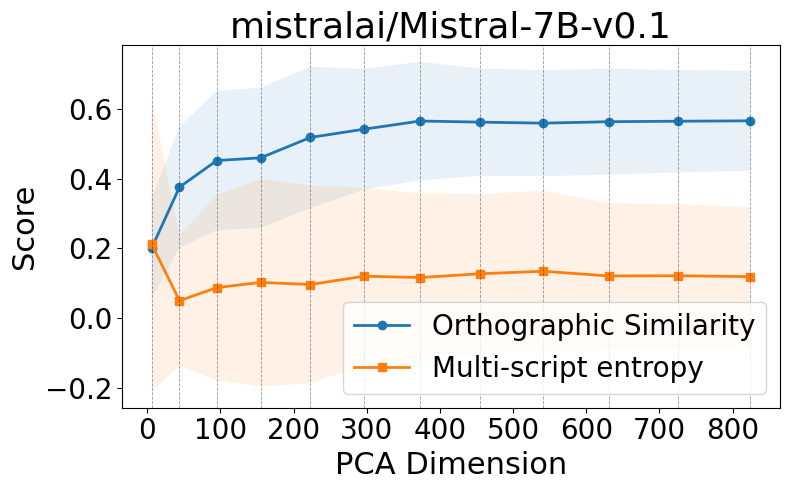

Plot data output: comp_supplement/low_energy_lt050_v1/figures/baseline/mistralai_Mistral-7B-v0.1_low12_baseline.plot_data.csv
Saved to: comp_supplement/low_energy_lt050_v1/figures/baseline/mistralai_Mixtral-8x7B-v0.1_low12_baseline.pdf


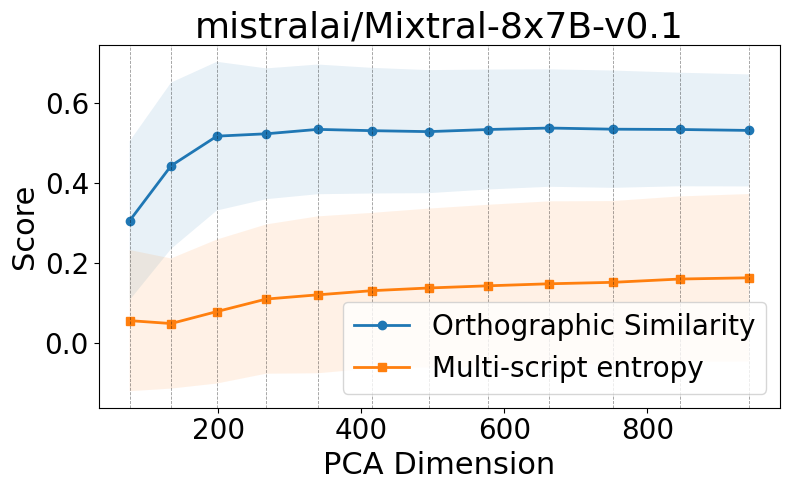

Plot data output: comp_supplement/low_energy_lt050_v1/figures/baseline/mistralai_Mixtral-8x7B-v0.1_low12_baseline.plot_data.csv
Saved to: comp_supplement/low_energy_lt050_v1/figures/baseline/gpt-oss_low12_baseline.pdf


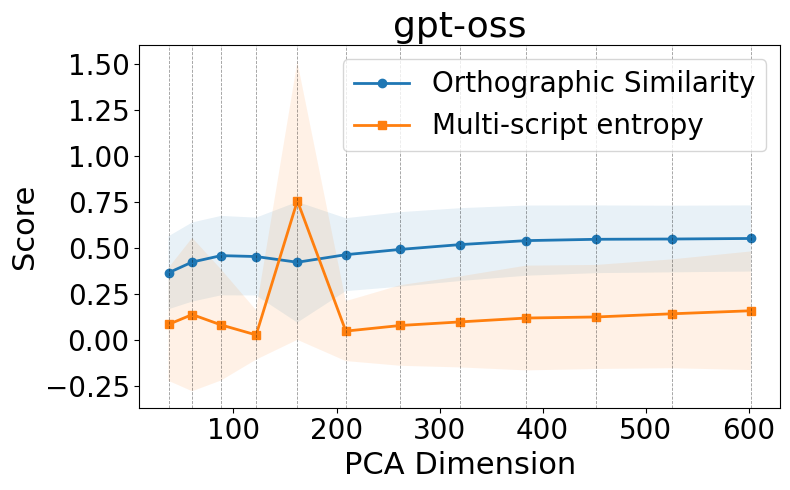

Plot data output: comp_supplement/low_energy_lt050_v1/figures/baseline/gpt-oss_low12_baseline.plot_data.csv
Baseline figure count: 3


In [40]:
import json
from pathlib import Path

import pandas as pd

from cluster_anlys.tool_fig import (
    plot_partition_level_morphology_vs_script_entropy,
    sanity_check_merged_partition_df,
)

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
OS_RESULT_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "metric_results"
    / "orthographic_similarity.csv"
)
MSE_RESULT_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "metric_results"
    / "multi_script_entropy.csv"
)
FIGURE_ROOT = SUPPLEMENT_ROOT / "figures" / "baseline"

if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}"
    )
selection_manifest = json.loads(
    SELECTION_MANIFEST_PATH.read_text(encoding="utf-8")
)

required_paths = (OS_RESULT_PATH, MSE_RESULT_PATH)
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(
        f"Baseline metric tables are required before plotting: {missing_paths}"
    )

os_results = pd.read_csv(OS_RESULT_PATH)
mse_results = pd.read_csv(MSE_RESULT_PATH)


def select_metric_curve(
    frame,
    *,
    model_name,
    metric,
    component,
    mean_column,
    std_column,
):
    selected = frame.loc[
        (frame["analysis_id"] == BASELINE_ANALYSIS_ID)
        & (frame["model_name"] == model_name)
        & (frame["metric"] == metric)
        & (frame["component"] == component)
        & frame["aggregation"].isin(("mean", "std")),
        ["scale", "aggregation", "value"],
    ].copy()
    if selected.empty:
        raise ValueError(
            f"No plotting observations for {model_name}, {metric}, {component}"
        )
    curve = selected.pivot(
        index="scale",
        columns="aggregation",
        values="value",
    ).reset_index()
    required_aggregations = {"mean", "std"}
    if not required_aggregations.issubset(curve.columns):
        raise ValueError(
            f"Missing mean or std for {model_name}, {metric}, {component}"
        )
    return (
        curve[["scale", "mean", "std"]]
        .rename(
            columns={
                "scale": "pca_dim",
                "mean": mean_column,
                "std": std_column,
            }
        )
        .sort_values("pca_dim")
        .reset_index(drop=True)
    )


FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
figure_paths = []
for model_name, model_info in selection_manifest["models"].items():
    morphology_curve = select_metric_curve(
        os_results,
        model_name=model_name,
        metric="orthographic_similarity",
        component="score",
        mean_column="global_mean",
        std_column="global_std",
    )
    script_curve = select_metric_curve(
        mse_results,
        model_name=model_name,
        metric="multi_script_entropy",
        component="raw",
        mean_column="mean_H",
        std_column="std_H",
    )
    merged_curve = morphology_curve.merge(
        script_curve,
        on="pca_dim",
        how="inner",
        validate="one_to_one",
    ).sort_values("pca_dim").reset_index(drop=True)
    expected_dimensions = tuple(int(value) for value in model_info["low_scales"])
    observed_dimensions = tuple(merged_curve["pca_dim"].astype(int))
    if observed_dimensions != expected_dimensions:
        raise AssertionError(
            f"Low12 plotting dimensions differ for {model_name}: "
            f"{observed_dimensions}"
        )
    sanity_check_merged_partition_df(merged_curve)

    output_path = (
        FIGURE_ROOT
        / f"{model_info['safe_model_name']}_low12_baseline.pdf"
    )
    data_path = output_path.with_name(
        f"{output_path.stem}.plot_data.csv"
    )
    merged_curve.to_csv(data_path, index=False)
    
    legend_loc="lower right"
    if model_name.startswith("gpt-oss"):
        legend_loc="upper right"
    saved_path = plot_partition_level_morphology_vs_script_entropy(
        df=merged_curve,
        model_name=model_name,
        title_fontsize=26,
        label_fontsize=22,
        tick_fontsize=20,
        legend_fontsize=20,
        legend_loc=legend_loc,
        save_path=output_path,
        show=True,
    )
    figure_paths.append(Path(saved_path))
    print(f"Plot data output: {data_path}")

if len(figure_paths) != 3:
    raise AssertionError(f"Expected three baseline figures, got {len(figure_paths)}")
print(f"Baseline figure count: {len(figure_paths)}")

<a id="section-2-5"></a>

## 2.5 Low12 Cluster Statistics

**Correspondence:** This component reproduces the two final full-partition cluster figures from `0_tool_fig.ipynb` over the independent low12 observation domain.

**Input:** The persisted 36-row baseline HDBSCAN partition manifest and its token-level partition CSV files.

**Flow:** Order each model's twelve PCA dimensions, assign scale indices 1 through 12, validate manifest cluster counts against non-noise token assignments, compute cluster-size mean, median, and quartiles, and render the same multi-model cluster-count and mean/median figures used by the main study.

**Output:** `low12_cluster_statistics.csv`, `low12_num_clusters.pdf`, and `low12_cluster_size_mean_median.pdf` under the low12 cluster-figure namespace.

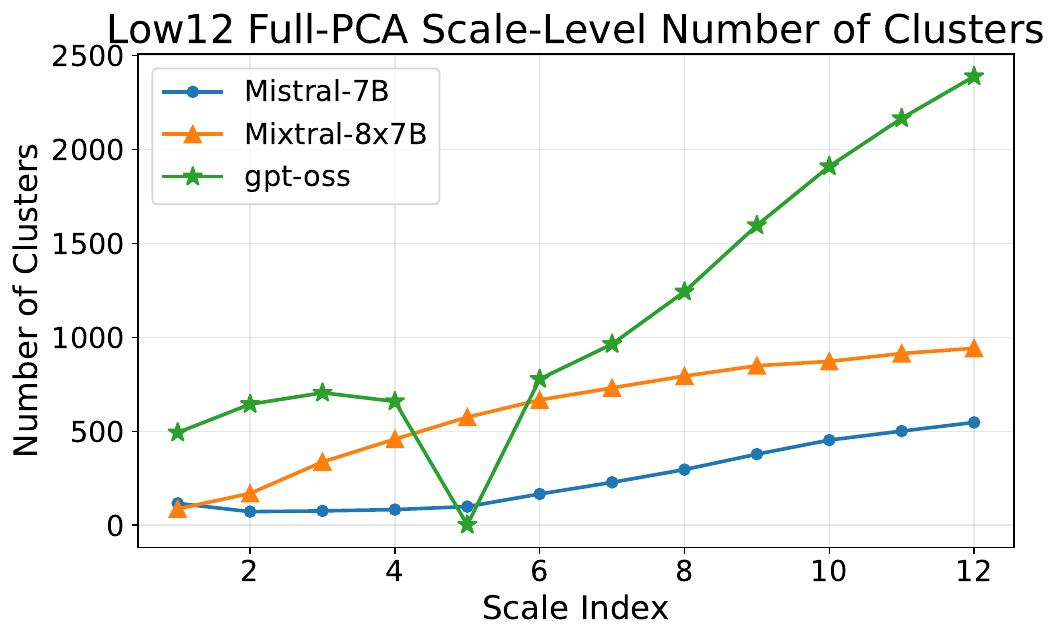

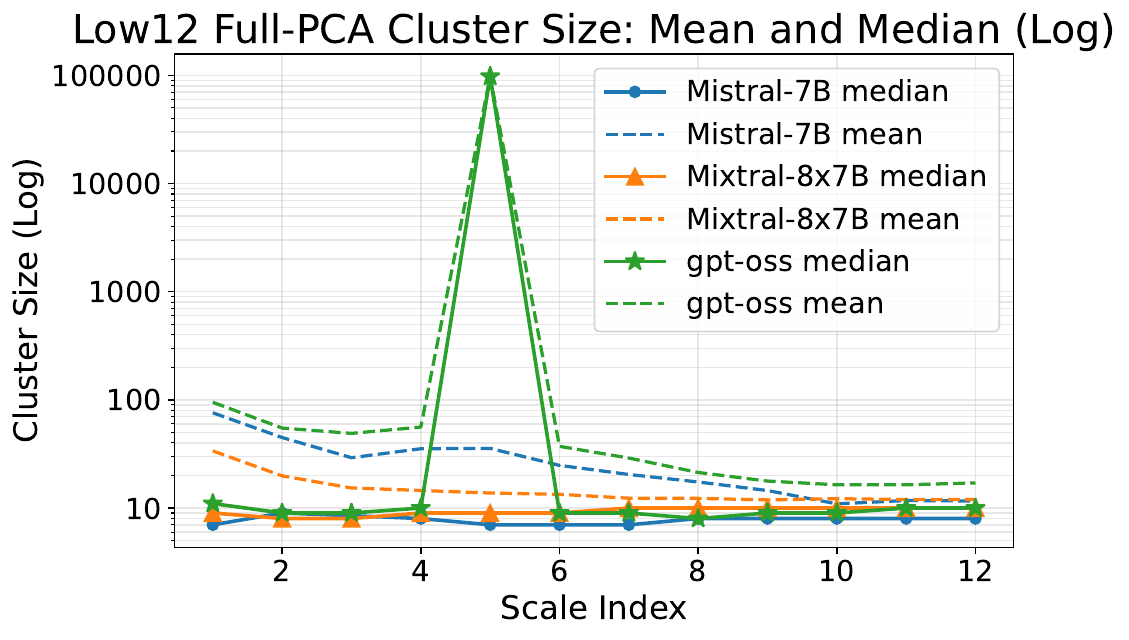

Cluster statistics figures: 2
Number-of-clusters figure: comp_supplement/low_energy_lt050_v1/figures/clusters/low12_num_clusters.pdf
Cluster-size figure: comp_supplement/low_energy_lt050_v1/figures/clusters/low12_cluster_size_mean_median.pdf


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
MANIFEST_PATH = (
    ROOT
    / "experiment_outputs"
    / BASELINE_ANALYSIS_ID
    / "manifests"
    / "hdbscan_partition_manifest.csv"
)
FIGURE_ROOT = ROOT / "figures" / "clusters"
STATISTICS_PATH = FIGURE_ROOT / "low12_cluster_statistics.csv"
NUM_CLUSTERS_PATH = FIGURE_ROOT / "low12_num_clusters.pdf"
CLUSTER_SIZE_PATH = FIGURE_ROOT / "low12_cluster_size_mean_median.pdf"

MODEL_SPECS = (
    {
        "model_name": "mistralai/Mistral-7B-v0.1",
        "label": "Mistral-7B",
        "marker": "o",
        "marker_size": 6,
    },
    {
        "model_name": "mistralai/Mixtral-8x7B-v0.1",
        "label": "Mixtral-8x7B",
        "marker": "^",
        "marker_size": 9,
    },
    {
        "model_name": "gpt-oss",
        "label": "gpt-oss",
        "marker": "*",
        "marker_size": 11,
    },
)
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Baseline partition manifest not found: {MANIFEST_PATH}"
    )
manifest = pd.read_csv(MANIFEST_PATH)
required_columns = {
    "model_name",
    "scale",
    "partition_csv_path",
    "n_clusters",
}
missing_columns = required_columns - set(manifest.columns)
if missing_columns:
    raise ValueError(
        f"Baseline partition manifest is missing columns: {sorted(missing_columns)}"
    )
if len(manifest) != 36:
    raise AssertionError(
        f"Expected 36 baseline partitions, got {len(manifest)}"
    )

statistics_rows = []
for model_spec in MODEL_SPECS:
    model_name = model_spec["model_name"]
    model_rows = (
        manifest.loc[manifest["model_name"] == model_name]
        .sort_values("scale")
        .reset_index(drop=True)
    )
    if len(model_rows) != 12:
        raise AssertionError(
            f"Expected twelve low12 partitions for {model_name}, got {len(model_rows)}"
        )
    for scale_index, row in enumerate(model_rows.itertuples(index=False), start=1):
        partition_path = Path(row.partition_csv_path)
        if not partition_path.is_file():
            raise FileNotFoundError(
                f"Partition CSV not found: {partition_path}"
            )
        partition = pd.read_csv(partition_path, usecols=["cluster_id"])
        cluster_ids = pd.to_numeric(
            partition["cluster_id"],
            errors="raise",
        ).astype(int)
        valid_cluster_ids = cluster_ids.loc[cluster_ids >= 0]
        cluster_sizes = (
            valid_cluster_ids.value_counts(sort=False)
            .to_numpy(dtype=float)
        )
        observed_cluster_count = int(len(cluster_sizes))
        expected_cluster_count = int(row.n_clusters)
        if observed_cluster_count != expected_cluster_count:
            raise AssertionError(
                f"Cluster count mismatch for {model_name}, scale={row.scale}: "
                f"manifest={expected_cluster_count}, observed={observed_cluster_count}"
            )
        if observed_cluster_count == 0:
            raise ValueError(
                f"No valid clusters for {model_name}, scale={row.scale}"
            )
        statistics_rows.append(
            {
                "model_name": model_name,
                "model_label": model_spec["label"],
                "scale_index": scale_index,
                "pca_dim": int(row.scale),
                "n_clusters_excl_noise": observed_cluster_count,
                "cluster_size_mean": float(np.mean(cluster_sizes)),
                "cluster_size_median": float(np.median(cluster_sizes)),
                "cluster_size_q25": float(np.quantile(cluster_sizes, 0.25)),
                "cluster_size_q75": float(np.quantile(cluster_sizes, 0.75)),
                "partition_csv_path": str(partition_path),
            }
        )

cluster_statistics = pd.DataFrame(statistics_rows)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
cluster_statistics.to_csv(STATISTICS_PATH, index=False)

plt.figure(figsize=(8, 5))
for model_spec in MODEL_SPECS:
    model_data = cluster_statistics.loc[
        cluster_statistics["model_name"] == model_spec["model_name"]
    ].sort_values("scale_index")
    plt.plot(
        model_data["scale_index"].to_numpy(),
        model_data["n_clusters_excl_noise"].to_numpy(),
        marker=model_spec["marker"],
        markersize=model_spec["marker_size"],
        linewidth=2,
        label=model_spec["label"],
    )
plt.xlabel("Scale Index", fontsize=LABEL_FONTSIZE)
plt.ylabel("Number of Clusters", fontsize=LABEL_FONTSIZE)
plt.title(
    "Low12 Full-PCA Scale-Level Number of Clusters",
    fontsize=TITLE_FONTSIZE,
)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
plt.legend(fontsize=LEGEND_FONTSIZE)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(NUM_CLUSTERS_PATH, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
for model_spec in MODEL_SPECS:
    model_data = cluster_statistics.loc[
        cluster_statistics["model_name"] == model_spec["model_name"]
    ].sort_values("scale_index")
    x = model_data["scale_index"].to_numpy()
    median = model_data["cluster_size_median"].to_numpy()
    mean = model_data["cluster_size_mean"].to_numpy()
    line = plt.plot(
        x,
        median,
        marker=model_spec["marker"],
        markersize=model_spec["marker_size"],
        linewidth=2,
        label=f"{model_spec['label']} median",
    )[0]
    plt.plot(
        x,
        mean,
        linestyle="--",
        linewidth=1.8,
        color=line.get_color(),
        label=f"{model_spec['label']} mean",
    )
plt.yscale("log")
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:g}")
)
plt.xlabel("Scale Index", fontsize=LABEL_FONTSIZE)
plt.ylabel("Cluster Size (Log)", fontsize=LABEL_FONTSIZE)
plt.title(
    "Low12 Full-PCA Cluster Size: Mean and Median (Log)",
    fontsize=TITLE_FONTSIZE,
)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
plt.legend(ncol=1, fontsize=LEGEND_FONTSIZE)
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(CLUSTER_SIZE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Cluster statistics: {STATISTICS_PATH}")
print(f"Number-of-clusters figure: {NUM_CLUSTERS_PATH}")
print(f"Cluster-size figure: {CLUSTER_SIZE_PATH}")

<a id="part-iii-robustness-analyses"></a>

# Part III: Robustness Analyses

This part evaluates the independent low12 baseline under cross-seed randomized-PCA stability, HDBSCAN parameter stability, global token permutation, and length-bucket permutation. Randomized PCA, HDBSCAN-parameter controls, and global token permutation each evaluate O-S and MS-E independently. The length-bucket control evaluates only O-S because it targets the token-length confound. Every branch preserves the same model-specific low12 observation domain and writes isolated supplementary outputs.


<a id="section-3-1-1"></a>

## 3.1.1 Cross-Seed Stability

### 3.1.1.1 Randomized PCA Representation Construction

**Correspondence.** This component isolates the representation-construction half of the randomized-PCA workflow used by `4_random PCA_hdbscan.ipynb`. It fits randomized PCA independently at every low12 dimension and every seed; it never obtains smaller spaces by slicing one larger randomized fit.

**Input.** `low12_selection_manifest.json` supplies the twelve model-specific dimensions and each original embedding-tensor path.

**Components.** `ScaleTask` declares each model-scale-seed identity. `RandomizedPCABuilder` adapts one independent randomized PCA fit. `RandomizedPCAOutputLayout` defines the five-file representation bundle. `RandomizedPCARepresentationPipeline` groups tasks by model, loads each original matrix once, and provides validated resume behavior through `RunPolicy`.

**Flow.** Load the selection contract, construct 3 × 12 × 8 = 288 tasks, convert one saved tensor per model to a CPU NumPy matrix, and build each requested randomized-PCA space independently.

**Output.** Complete randomized-PCA bundles and a typed `RepresentationManifest` are written under the isolated cross-seed-stability representation root. The next component reads only this persistent manifest and its matrix paths.

In [6]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from cluster_anlys.pipeline_core import RunPolicy, ScaleTask
from cluster_anlys.representation_pipeline import (
    RandomizedPCABuilder,
    RandomizedPCAOutputLayout,
    RandomizedPCARepresentationPipeline,
    RepresentationManifest,
)

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
RANDOM_PCA_ANALYSIS_ID = "low12_random_pca"
RANDOM_PCA_SEEDS = (
    0,
    42,
    1000,
    9999,
    1813382118,
    827307999,
    1627694678,
    1911784257,
)
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
REPRESENTATION_ROOT = (
    SUPPLEMENT_ROOT / "cross_seed_stability" / "representations"
)

if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}"
    )
selection_manifest = json.loads(
    SELECTION_MANIFEST_PATH.read_text(encoding="utf-8")
)
if selection_manifest.get("analysis_id") != SELECTION_ANALYSIS_ID:
    raise ValueError("Low12 selection manifest analysis id mismatch")

random_pca_tasks = tuple(
    ScaleTask(
        analysis_id=RANDOM_PCA_ANALYSIS_ID,
        model_name=model_name,
        space_name=model_info["space_name"],
        scale=int(scale),
        source="randomized_pca",
        seed_type="pca_seed",
        seed=seed,
    )
    for model_name, model_info in selection_manifest["models"].items()
    for seed in RANDOM_PCA_SEEDS
    for scale in model_info["low_scales"]
)
if len(random_pca_tasks) != 288:
    raise AssertionError(
        f"Expected 288 randomized-PCA tasks, got {len(random_pca_tasks)}"
    )
if len({task.task_key for task in random_pca_tasks}) != 288:
    raise AssertionError("Randomized-PCA tasks are not unique")


def load_model_matrix(model_name):
    tensor_path = Path(
        selection_manifest["models"][model_name]["tensor_path"]
    )
    if not tensor_path.is_file():
        raise FileNotFoundError(f"Embedding tensor not found: {tensor_path}")
    tensor = torch.load(tensor_path, map_location="cpu")
    if not isinstance(tensor, torch.Tensor):
        raise TypeError(f"Expected a tensor at {tensor_path}")
    if tensor.ndim != 2:
        raise ValueError(
            f"Embedding tensor must be 2D, got shape={tuple(tensor.shape)}"
        )
    return tensor.detach().cpu().to(torch.float32).numpy()


representation_layout = RandomizedPCAOutputLayout(REPRESENTATION_ROOT)
representation_manifest_path = representation_layout.manifest_path(
    RANDOM_PCA_ANALYSIS_ID
)
representation_manifest = None
representation_run = None

representation_run = RandomizedPCARepresentationPipeline(
    builder=RandomizedPCABuilder(
        n_oversamples=10,
        power_iteration_normalizer="auto",
        iterated_power="auto",
    ),
    output_layout=representation_layout,
    matrix_loader=load_model_matrix,
    run_policy=RunPolicy(existing_output="resume"),
).run(random_pca_tasks)
representation_manifest = representation_run.manifest

if representation_run is not None:
    # display(
    #     pd.DataFrame(
    #         [record.to_dict() for record in representation_run.report.records]
    #     )
    # )
    pass

if representation_manifest is not None:
    if len(representation_manifest.rows) != 288:
        raise AssertionError(
            "The randomized-PCA manifest must contain 288 representations"
        )
    if any(row.n_features != row.task.scale for row in representation_manifest.rows):
        raise AssertionError("A representation width differs from its task scale")
    # display(representation_manifest.to_frame())

print(f"Randomized-PCA representation manifest: {representation_manifest_path}")

[✓] Randomized PCA finished | model=mistralai/Mistral-7B-v0.1 dim=6 seed=0 time=0.89s cum_var=0.033450
[✓] Saved to: comp_supplement/low_energy_lt050_v1/cross_seed_stability/.representations.pca.04e7j9_8/mistralai/Mistral-7B-v0.1/random_pca/seed_0/pca_dim_6
Memory Cleaned.
[✓] Randomized PCA finished | model=mistralai/Mistral-7B-v0.1 dim=44 seed=0 time=1.65s cum_var=0.065845
[✓] Saved to: comp_supplement/low_energy_lt050_v1/cross_seed_stability/.representations.pca.r5239a6y/mistralai/Mistral-7B-v0.1/random_pca/seed_0/pca_dim_44
Memory Cleaned.
[✓] Randomized PCA finished | model=mistralai/Mistral-7B-v0.1 dim=95 seed=0 time=1.89s cum_var=0.098083
[✓] Saved to: comp_supplement/low_energy_lt050_v1/cross_seed_stability/.representations.pca.e2se_3p4/mistralai/Mistral-7B-v0.1/random_pca/seed_0/pca_dim_95
Memory Cleaned.
[✓] Randomized PCA finished | model=mistralai/Mistral-7B-v0.1 dim=155 seed=0 time=2.34s cum_var=0.130116
[✓] Saved to: comp_supplement/low_energy_lt050_v1/cross_seed_stabilit

<a id="section-3-1-1-2"></a>

### 3.1.1.2 Random-PCA HDBSCAN

**Correspondence.** This component is the clustering half of `4_random PCA_hdbscan.ipynb` and the randomized branch represented by the original 4/4r notebook group.

**Input.** The persistent randomized-PCA `RepresentationManifest` and its 288 independently saved `X_pca.npy` matrices.

**Components.** `SavedPerScaleProvider` loads one saved matrix through the explicit unpadded-seed resolver. `RowL2Normalizer` applies the same row-wise normalization as the deterministic baseline. `HDBSCANAdapter` fixes the baseline clustering parameters. `ClusteringPipeline` writes canonical partitions and a `PartitionManifest`.

**Flow.** Reconstruct all task identities from the representation manifest, load each exact saved space, normalize rows, and run the unchanged HDBSCAN configuration.

**Output.** A 288-row random-PCA HDBSCAN `PartitionManifest` under the low12 experiment-output root. O-S and MS-E consume this file independently.

In [7]:
from pathlib import Path

import pandas as pd

from cluster_anlys.clustering_pipeline import (
    ClusteringOutputLayout,
    ClusteringPipeline,
    HDBSCANAdapter,
    PartitionManifest,
    RowL2Normalizer,
    SavedPerScaleProvider,
)
from cluster_anlys.pipeline_core import RunPolicy
from cluster_anlys.representation_pipeline import (
    RepresentationManifest,
    randomized_pca_matrix_path,
)

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
RANDOM_PCA_ANALYSIS_ID = "low12_random_pca"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
REPRESENTATION_ROOT = (
    SUPPLEMENT_ROOT / "cross_seed_stability" / "representations"
)
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
REPRESENTATION_MANIFEST_PATH = (
    REPRESENTATION_ROOT
    / RANDOM_PCA_ANALYSIS_ID
    / "manifests"
    / "randomized_pca_representation_manifest.csv"
)

clustering_layout = ClusteringOutputLayout(OUTPUT_ROOT)
partition_manifest_path = clustering_layout.manifest_path(
    RANDOM_PCA_ANALYSIS_ID,
    "hdbscan",
)
partition_manifest = None
clustering_run = None

if not REPRESENTATION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Randomized-PCA representations are required before HDBSCAN: "
        f"{REPRESENTATION_MANIFEST_PATH}"
    )
representation_manifest = RepresentationManifest.read_csv(
    REPRESENTATION_MANIFEST_PATH
)
random_pca_tasks = tuple(row.task for row in representation_manifest.rows)
if len(random_pca_tasks) != 288:
    raise AssertionError(
        f"Expected 288 randomized-PCA tasks, got {len(random_pca_tasks)}"
    )
pipeline = ClusteringPipeline(
    provider=SavedPerScaleProvider(
        REPRESENTATION_ROOT,
        path_resolver=randomized_pca_matrix_path,
    ),
    transforms=(RowL2Normalizer(),),
    method=HDBSCANAdapter(
        min_cluster_size=5,
        min_samples=5,
        metric="euclidean",
        cluster_selection_method="eom",
        cluster_selection_epsilon=0.0,
    ),
    output_layout=clustering_layout,
    run_policy=RunPolicy(existing_output="resume"),
)
clustering_run = pipeline.run(random_pca_tasks)
partition_manifest = clustering_run.manifest

if clustering_run is not None:
    # display(
    #     pd.DataFrame(
    #         [record.to_dict() for record in clustering_run.report.records]
    #     )
    # )
    pass

if partition_manifest is not None:
    if len(partition_manifest.rows) != 288:
        raise AssertionError("The random-PCA manifest must contain 288 partitions")
    if any(row.task.source != "randomized_pca" for row in partition_manifest.rows):
        raise AssertionError("The random-PCA manifest contains another source")
    # display(partition_manifest.to_frame())

print(f"Random-PCA partition manifest: {partition_manifest_path}")

[i] HDBSCAN params | min_cluster_size=5, min_samples=5, metric=euclidean, cluster_selection_method=eom, cluster_selection_epsilon=0.0
[2026-08-10 00:51:48.187] [CUML] [warning] Using data on device memory because knn_n_clusters = 1.
[✓] cuML HDBSCAN finished (4.51s)
[i] HDBSCAN params | min_cluster_size=5, min_samples=5, metric=euclidean, cluster_selection_method=eom, cluster_selection_epsilon=0.0
[2026-08-10 00:51:52.921] [CUML] [warning] Using data on device memory because knn_n_clusters = 1.
[✓] cuML HDBSCAN finished (4.92s)
[i] HDBSCAN params | min_cluster_size=5, min_samples=5, metric=euclidean, cluster_selection_method=eom, cluster_selection_epsilon=0.0
[2026-08-10 00:51:58.070] [CUML] [warning] Using data on device memory because knn_n_clusters = 1.
[✓] cuML HDBSCAN finished (5.58s)
[i] HDBSCAN params | min_cluster_size=5, min_samples=5, metric=euclidean, cluster_selection_method=eom, cluster_selection_epsilon=0.0
[2026-08-10 00:52:03.881] [CUML] [warning] Using data on device m

<a id="section-3-1-1-3"></a>

### 3.1.1.3 Random-PCA Orthographic Similarity

**Correspondence.** This component applies the O-S logic from the original 5/5r notebook group to the random-PCA partitions.

**Input.** The persistent 288-row random-PCA HDBSCAN `PartitionManifest`.

**Components.** `OrthographicSimilarityMetric` implements cluster-level O-S, including the fixed large-cluster approximation. `MetricOutputLayout` isolates metric files. `PartitionMetricPipeline` evaluates every partition and writes a canonical long-form result table. `RunPolicy` validates complete outputs before resume.

**Flow.** Read the partition manifest, prepare one tokenizer per model, evaluate O-S independently for every seed and scale, and retain both cluster details and partition summaries.

**Output.** Random-PCA O-S detail files and `orthographic_similarity.csv`. The statistics component reads only the aggregate long-form table.

In [8]:
from pathlib import Path

from cluster_anlys.metric_pipeline import (
    MetricOutputLayout,
    MetricResultTable,
    OrthographicSimilarityMetric,
    PartitionMetricPipeline,
    orthographic_similarity_summary_frame,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
RANDOM_PCA_ANALYSIS_ID = "low12_random_pca"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
PARTITION_MANIFEST_PATH = (
    OUTPUT_ROOT
    / RANDOM_PCA_ANALYSIS_ID
    / "manifests"
    / "hdbscan_partition_manifest.csv"
)

metric_layout = MetricOutputLayout(OUTPUT_ROOT)
os_result_path = metric_layout.result_table_path(
    RANDOM_PCA_ANALYSIS_ID,
    "orthographic_similarity",
)
os_results = None
os_run = None

if not PARTITION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Random-PCA partition manifest is required before O-S: "
        f"{PARTITION_MANIFEST_PATH}"
    )
os_run = PartitionMetricPipeline(
    metric=OrthographicSimilarityMetric(),
    output_layout=metric_layout,
    run_policy=RunPolicy(existing_output="resume"),
).run(PARTITION_MANIFEST_PATH)
os_results = os_run.results

if os_results is not None:
    task_keys = {row.task.task_key for row in os_results.rows}
    if len(task_keys) != 288:
        raise AssertionError(
            f"Expected O-S results for 288 tasks, got {len(task_keys)}"
        )
    if {row.metric for row in os_results.rows} != {"orthographic_similarity"}:
        raise AssertionError("Random-PCA O-S table contains another metric")
    os_summary = orthographic_similarity_summary_frame(os_results)
    display(
        os_summary.set_index("model_name")
        .loc[
            [
                "mistralai/Mistral-7B-v0.1",
                "mistralai/Mixtral-8x7B-v0.1",
                "gpt-oss",
            ]
        ]
        .reset_index()
    )

print(f"Random-PCA O-S result table: {os_result_path}")

,model_name,space_name,pca_seed,pca_dim,l2_norm,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,global_mean,global_std,n_clusters
0,mistralai/Mistral-7B-v0.1,output_proj,0,6,True,5,5,euclidean,eom,0.0,0.189472,0.138199,128
1,mistralai/Mistral-7B-v0.1,output_proj,0,44,True,5,5,euclidean,eom,0.0,0.389381,0.187481,64
2,mistralai/Mistral-7B-v0.1,output_proj,0,95,True,5,5,euclidean,eom,0.0,0.441966,0.195085,65
3,mistralai/Mistral-7B-v0.1,output_proj,0,155,True,5,5,euclidean,eom,0.0,0.456459,0.193604,74
4,mistralai/Mistral-7B-v0.1,output_proj,0,223,True,5,5,euclidean,eom,0.0,0.527235,0.189925,102
...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,gpt-oss,output_proj,1911784257,320,True,5,5,euclidean,eom,0.0,0.518755,0.194464,1231
284,gpt-oss,output_proj,1911784257,384,True,5,5,euclidean,eom,0.0,0.538912,0.190283,1533
285,gpt-oss,output_proj,1911784257,452,True,5,5,euclidean,eom,0.0,0.554478,0.184254,1858
286,gpt-oss,output_proj,1911784257,525,True,5,5,euclidean,eom,0.0,0.556212,0.180806,2132


Random-PCA O-S result table: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_random_pca/metric_results/orthographic_similarity.csv


<a id="section-3-1-1-4"></a>

### 3.1.1.4 Random-PCA Multi-Script Entropy

**Correspondence.** This component applies the MS-E logic from the original 6/6r notebook group to the same random-PCA partitions. It is a sibling of O-S, not a downstream consumer of O-S.

**Input.** The persistent 288-row random-PCA HDBSCAN `PartitionManifest`.

**Components.** `MultiScriptEntropyMetric` prepares the model script cache and computes raw and normalized entropy. `MetricOutputLayout`, `PartitionMetricPipeline`, and `RunPolicy` provide the same isolated persistence and resume contract used by O-S.

**Flow.** Read the partition manifest independently, prepare model resources, evaluate every seed-scale partition, and save cluster- and partition-level results. Decoded token text remains in memory only and is never persisted.

**Output.** Random-PCA MS-E detail files and `multi_script_entropy.csv`. No O-S runtime object is required.

In [9]:
from pathlib import Path

from cluster_anlys.metric_pipeline import (
    MetricOutputLayout,
    MetricResultTable,
    MultiScriptEntropyMetric,
    PartitionMetricPipeline,
    multi_script_entropy_summary_frame,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
RANDOM_PCA_ANALYSIS_ID = "low12_random_pca"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
PARTITION_MANIFEST_PATH = (
    OUTPUT_ROOT
    / RANDOM_PCA_ANALYSIS_ID
    / "manifests"
    / "hdbscan_partition_manifest.csv"
)

metric_layout = MetricOutputLayout(OUTPUT_ROOT)
mse_result_path = metric_layout.result_table_path(
    RANDOM_PCA_ANALYSIS_ID,
    "multi_script_entropy",
)
mse_results = None
mse_run = None

if not PARTITION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Random-PCA partition manifest is required before MS-E: "
        f"{PARTITION_MANIFEST_PATH}"
    )
mse_run = PartitionMetricPipeline(
    metric=MultiScriptEntropyMetric(),
    output_layout=metric_layout,
    run_policy=RunPolicy(existing_output="resume"),
).run(PARTITION_MANIFEST_PATH)
mse_results = mse_run.results

if mse_results is not None:
    task_keys = {row.task.task_key for row in mse_results.rows}
    if len(task_keys) != 288:
        raise AssertionError(
            f"Expected MS-E results for 288 tasks, got {len(task_keys)}"
        )
    if {row.metric for row in mse_results.rows} != {"multi_script_entropy"}:
        raise AssertionError("Random-PCA MS-E table contains another metric")
    mse_summary = multi_script_entropy_summary_frame(mse_results)
    display(
        mse_summary.set_index("model_name")
        .loc[
            [
                "mistralai/Mistral-7B-v0.1",
                "mistralai/Mixtral-8x7B-v0.1",
                "gpt-oss",
            ]
        ]
        .reset_index()
    )

print(f"Random-PCA MS-E result table: {mse_result_path}")

,model_name,space_name,pca_seed,pca_dim,l2_norm,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,num_clusters,mean_H,std_H,mean_H_norm,std_H_norm
0,mistralai/Mistral-7B-v0.1,output_proj,0,6,True,5,5,euclidean,eom,0.0,128,0.232960,0.429211,0.068494,0.126194
1,mistralai/Mistral-7B-v0.1,output_proj,0,44,True,5,5,euclidean,eom,0.0,64,0.036172,0.132757,0.010635,0.039032
2,mistralai/Mistral-7B-v0.1,output_proj,0,95,True,5,5,euclidean,eom,0.0,65,0.055456,0.271188,0.016305,0.079733
3,mistralai/Mistral-7B-v0.1,output_proj,0,155,True,5,5,euclidean,eom,0.0,74,0.114210,0.322279,0.033579,0.094755
4,mistralai/Mistral-7B-v0.1,output_proj,0,223,True,5,5,euclidean,eom,0.0,102,0.111336,0.282349,0.032734,0.083015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,gpt-oss,output_proj,1911784257,320,True,5,5,euclidean,eom,0.0,1231,0.086340,0.224477,0.025641,0.066664
284,gpt-oss,output_proj,1911784257,384,True,5,5,euclidean,eom,0.0,1533,0.109697,0.266537,0.032577,0.079155
285,gpt-oss,output_proj,1911784257,452,True,5,5,euclidean,eom,0.0,1858,0.119610,0.282501,0.035521,0.083896
286,gpt-oss,output_proj,1911784257,525,True,5,5,euclidean,eom,0.0,2132,0.133987,0.293741,0.039791,0.087233


Random-PCA MS-E result table: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_random_pca/metric_results/multi_script_entropy.csv


<a id="section-3-1-1-5"></a>

### 3.1.1.5 Baseline-vs-Random Statistics and Seed Aggregation

**Correspondence.** This component reproduces the cross-scale agreement logic used by the original correlation and report notebooks after the 5r/6r metrics are available.

**Input.** Four persistent canonical tables: baseline O-S, baseline MS-E, random-PCA O-S, and random-PCA MS-E. The low12 selection manifest supplies the exact model and space identities.

**Components.** `CurveQuery` selects one explicit twelve-point curve. `StatisticsPipeline` aligns each random seed with the baseline using exact scales. `SpearmanStatistic`, `MAEStatistic`, and `R2Statistic` produce rho plus its p-value, absolute error, and baseline-as-reference directional R². `aggregate_seed_metric_results` separately converts seed-level metric means into canonical `seed_mean` and sample `seed_std` curves.

**Flow.** Compare 3 models × 8 seeds × 2 metrics, require twelve aligned scales for every comparison, persist the long-form statistics, and aggregate the eight control curves at every model-scale-metric identity.

**Output.** `random_pca_vs_baseline.csv` and a canonical seed-aggregate metric table. Pearson is intentionally excluded, and the p-value is retained only as inferential output rather than an agreement magnitude.

In [46]:
import json
from pathlib import Path

from cluster_anlys.metric_pipeline import (
    MetricResultTable,
    aggregate_seed_metric_results,
)
from cluster_anlys.statistics_pipeline import (
    CurveQuery,
    MAEStatistic,
    R2Statistic,
    SpearmanStatistic,
    StatisticResultTable,
    StatisticsPipeline,
)

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
RANDOM_PCA_ANALYSIS_ID = "low12_random_pca"
SEED_AGGREGATE_ANALYSIS_ID = "low12_random_pca_seed_aggregate"
RANDOM_PCA_SEEDS = (
    0,
    42,
    1000,
    9999,
    1813382118,
    827307999,
    1627694678,
    1911784257,
)
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
BASELINE_OS_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "metric_results"
    / "orthographic_similarity.csv"
)
BASELINE_MSE_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "metric_results"
    / "multi_script_entropy.csv"
)
RANDOM_OS_PATH = (
    OUTPUT_ROOT
    / RANDOM_PCA_ANALYSIS_ID
    / "metric_results"
    / "orthographic_similarity.csv"
)
RANDOM_MSE_PATH = (
    OUTPUT_ROOT
    / RANDOM_PCA_ANALYSIS_ID
    / "metric_results"
    / "multi_script_entropy.csv"
)
STATISTICS_PATH = (
    SUPPLEMENT_ROOT
    / "statistics"
    / "cross_seed_random_pca_vs_baseline_raw_mse.csv"
)
SEED_AGGREGATE_PATH = (
    SUPPLEMENT_ROOT
    / "cross_seed_stability"
    / "random_pca_seed_aggregate.csv"
)

if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}"
    )
selection_manifest = json.loads(
    SELECTION_MANIFEST_PATH.read_text(encoding="utf-8")
)

statistics_results = None
seed_aggregate_results = None
metric_paths = (
    BASELINE_OS_PATH,
    BASELINE_MSE_PATH,
    RANDOM_OS_PATH,
    RANDOM_MSE_PATH,
)

missing_paths = [path for path in metric_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(
        f"Baseline and random-PCA metric tables are required: {missing_paths}"
    )
baseline_results = MetricResultTable.combine(
    MetricResultTable.read_csv(BASELINE_OS_PATH),
    MetricResultTable.read_csv(BASELINE_MSE_PATH),
)
random_results = MetricResultTable.combine(
    MetricResultTable.read_csv(RANDOM_OS_PATH),
    MetricResultTable.read_csv(RANDOM_MSE_PATH),
)
combined_results = MetricResultTable.combine(
    baseline_results,
    random_results,
)

if STATISTICS_PATH.is_file():
    statistics_results = StatisticResultTable.read_csv(STATISTICS_PATH)
    print(f"REUSE random-PCA statistics: {STATISTICS_PATH}")
else:
    comparison_tables = []
    for model_name, model_info in selection_manifest["models"].items():
        for seed in RANDOM_PCA_SEEDS:
            for metric, component in (
                ("orthographic_similarity", "score"),
                ("multi_script_entropy", "raw"),
            ):
                queries = (
                    CurveQuery(
                        analysis_id=BASELINE_ANALYSIS_ID,
                        model_name=model_name,
                        source="full_pca_prefix",
                        metric=metric,
                        component=component,
                        aggregation="mean",
                        space_name=model_info["space_name"],
                        partition_method="hdbscan",
                    ),
                    CurveQuery(
                        analysis_id=RANDOM_PCA_ANALYSIS_ID,
                        model_name=model_name,
                        source="randomized_pca",
                        seed_type="pca_seed",
                        seed=seed,
                        metric=metric,
                        component=component,
                        aggregation="mean",
                        space_name=model_info["space_name"],
                        partition_method="hdbscan",
                    ),
                )
                comparison = StatisticsPipeline(
                    statistics=(
                        SpearmanStatistic(),
                        MAEStatistic(),
                        R2Statistic(),
                    ),
                    alignment_strategy="exact",
                    pair_mode="reference_only",
                ).run(combined_results, queries)
                if any(row.n_points != 12 for row in comparison.results.rows):
                    raise AssertionError(
                        "Every random-PCA comparison must use twelve scales"
                    )
                comparison_tables.append(comparison.results)
    statistics_results = StatisticResultTable.combine(*comparison_tables)
    statistics_results.write_csv(STATISTICS_PATH)

expected_aggregate = aggregate_seed_metric_results(
    random_results,
    input_analysis_id=RANDOM_PCA_ANALYSIS_ID,
    input_source="randomized_pca",
    seed_type="pca_seed",
    expected_seeds=RANDOM_PCA_SEEDS,
    output_analysis_id=SEED_AGGREGATE_ANALYSIS_ID,
    output_source="randomized_pca_seed_aggregate",
    input_aggregation="mean",
    ddof=1,
)
if SEED_AGGREGATE_PATH.is_file():
    seed_aggregate_results = MetricResultTable.read_csv(SEED_AGGREGATE_PATH)
    if seed_aggregate_results != expected_aggregate:
        raise ValueError(
            f"Existing seed aggregate differs: {SEED_AGGREGATE_PATH}"
        )
    print(f"REUSE random-PCA seed aggregate: {SEED_AGGREGATE_PATH}")
else:
    expected_aggregate.write_csv(SEED_AGGREGATE_PATH)
    seed_aggregate_results = expected_aggregate

if statistics_results is not None:
    if len(statistics_results.rows) != 192:
        raise AssertionError(
            f"Expected 192 statistic observations, got {len(statistics_results.rows)}"
        )
    if {row.statistic for row in statistics_results.rows} != {
        "spearman",
        "mae",
        "r2",
    }:
        raise AssertionError("Cross-seed statistics contain an unexpected statistic")
    if any(row.n_points != 12 for row in statistics_results.rows):
        raise AssertionError("Cross-seed statistics must use exactly twelve scales")
    # display(statistics_results.to_frame())

if seed_aggregate_results is not None:
    desired_rows = tuple(
        row
        for row in seed_aggregate_results.rows
        if (row.metric, row.component)
        in {
            ("orthographic_similarity", "score"),
            ("multi_script_entropy", "raw"),
        }
    )
    if len(desired_rows) != 144:
        raise AssertionError(
            f"Expected 144 plotted seed-aggregate observations, got {len(desired_rows)}"
        )
    if {row.aggregation for row in desired_rows} != {"seed_mean", "seed_std"}:
        raise AssertionError("Seed aggregate must contain mean and sample SD")
    # display(seed_aggregate_results.to_frame())

print(f"Cross-seed statistics table: {STATISTICS_PATH}")
print(f"Random-PCA seed aggregate table: {SEED_AGGREGATE_PATH}")

ValueError: Existing seed aggregate differs: comp_supplement/low_energy_lt050_v1/cross_seed_stability/random_pca_seed_aggregate.csv

<a id="section-3-1-1-6"></a>

### 3.1.1.6 Cross-Seed Supplementary Curves

**Correspondence.** This component replaces the original per-seed plotting glue with the paper-facing supplementary presentation for randomized-PCA stability.

**Input.** The baseline O-S/MS-E result tables, the persistent cross-seed aggregate table, and the low12 selection manifest.

**Components.** `CurveQuery` explicitly chooses each baseline, seed-mean, and seed-SD curve. `LineSpec` attaches the SD curve as uncertainty around the random-PCA mean. `FigureSpec` declares each two-line comparison. `PlotPipeline` and `MatplotlibBackend` save both the figure and its exact plotting-data table.

**Flow.** For each model and each lexical metric, draw the deterministic low12 baseline against the randomized-PCA mean with a sample-SD band. Individual seed curves are intentionally omitted from the main supplementary figures.

**Output.** Six PDF figures and six sibling plotting-data tables under `figures/cross_seed_stability`.

In [42]:
import json
from pathlib import Path

from IPython.display import IFrame, display

from cluster_anlys.metric_pipeline import MetricResultTable
from cluster_anlys.plotting_pipeline import (
    AxisSpec,
    FigureSpec,
    LineSpec,
    MatplotlibBackend,
    PlotPipeline,
)
from cluster_anlys.statistics_pipeline import CurveQuery

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
SEED_AGGREGATE_ANALYSIS_ID = "low12_random_pca_seed_aggregate"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
BASELINE_OS_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "metric_results"
    / "orthographic_similarity.csv"
)
BASELINE_MSE_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "metric_results"
    / "multi_script_entropy.csv"
)
SEED_AGGREGATE_PATH = (
    SUPPLEMENT_ROOT
    / "cross_seed_stability"
    / "random_pca_seed_aggregate.csv"
)
FIGURE_ROOT = SUPPLEMENT_ROOT / "figures" / "cross_seed_stability"


def display_figure_result(figure_path, data_path, status):
    display(
        IFrame(
            src=f"/files/{figure_path.as_posix()}",
            width=900,
            height=600,
        )
    )
    print(f"Figure status: {status}")
    print(f"Figure output: {figure_path}")
    print(f"Plot data output: {data_path}")

if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}"
    )
selection_manifest = json.loads(
    SELECTION_MANIFEST_PATH.read_text(encoding="utf-8")
)


def baseline_query(model_name, space_name, metric, component):
    return CurveQuery(
        analysis_id=BASELINE_ANALYSIS_ID,
        model_name=model_name,
        source="full_pca_prefix",
        metric=metric,
        component=component,
        aggregation="mean",
        space_name=space_name,
        partition_method="hdbscan",
    )


def aggregate_query(
    model_name,
    space_name,
    metric,
    component,
    aggregation,
):
    return CurveQuery(
        analysis_id=SEED_AGGREGATE_ANALYSIS_ID,
        model_name=model_name,
        source="randomized_pca_seed_aggregate",
        metric=metric,
        component=component,
        aggregation=aggregation,
        space_name=space_name,
        partition_method="hdbscan",
    )


metric_specs = (
    (
        "orthographic_similarity",
        "score",
        "Orthographic Similarity",
        "os",
    ),
    (
        "multi_script_entropy",
        "raw",
        "Multi-Script Entropy",
        "mse_raw",
    ),
)
figure_paths = []

required_paths = (
    BASELINE_OS_PATH,
    BASELINE_MSE_PATH,
    SEED_AGGREGATE_PATH,
)
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(
        f"Metric and seed-aggregate tables are required: {missing_paths}"
    )
plot_results = MetricResultTable.combine(
    MetricResultTable.read_csv(BASELINE_OS_PATH),
    MetricResultTable.read_csv(BASELINE_MSE_PATH),
    MetricResultTable.read_csv(SEED_AGGREGATE_PATH),
)
for model_name, model_info in selection_manifest["models"].items():
    for metric, component, y_label, short_name in metric_specs:
        output_path = (
            FIGURE_ROOT
            / f"{model_info['safe_model_name']}_{short_name}.pdf"
        )
        data_path = PlotPipeline.data_path_for(output_path)
        if output_path.is_file() and data_path.is_file():
            figure_paths.append(output_path)
            display_figure_result(output_path, data_path, "REUSED")
            continue
        if output_path.exists() or data_path.exists():
            raise FileExistsError(
                f"Incomplete cross-seed figure output: {output_path}, {data_path}"
            )
        space_name = model_info["space_name"]
        spec = FigureSpec(
            lines=(
                LineSpec(
                    curve_query=baseline_query(
                        model_name,
                        space_name,
                        metric,
                        component,
                    ),
                    label="Low12 full-PCA baseline",
                    color="black",
                    marker="o",
                ),
                LineSpec(
                    curve_query=aggregate_query(
                        model_name,
                        space_name,
                        metric,
                        component,
                        "seed_mean",
                    ),
                    uncertainty_query=aggregate_query(
                        model_name,
                        space_name,
                        metric,
                        component,
                        "seed_std",
                    ),
                    label="Randomized PCA mean ± SD",
                    color="tab:blue",
                    marker="s",
                ),
            ),
            x_axis=AxisSpec("PCA dimension"),
            y_axis=AxisSpec(y_label),
            output_path=output_path,
            title=f"Cross-seed stability: {model_name}",
            x_scale="log",
        )
        plot_run = PlotPipeline(
            backend=MatplotlibBackend(),
        ).run(plot_results, spec)
        figure_paths.append(plot_run.figure_path)
        # display(plot_run.plot_data.to_frame())
        display_figure_result(plot_run.figure_path, plot_run.data_path, "GENERATED")

if len(figure_paths) != 6:
    raise AssertionError(f"Expected six cross-seed figures, got {len(figure_paths)}")
print(f"Cross-seed supplementary figure count: {len(figure_paths)}")

Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/mistralai_Mistral-7B-v0.1_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/mistralai_Mistral-7B-v0.1_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/mistralai_Mistral-7B-v0.1_mse.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/mistralai_Mistral-7B-v0.1_mse.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/mistralai_Mixtral-8x7B-v0.1_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/mistralai_Mixtral-8x7B-v0.1_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/mistralai_Mixtral-8x7B-v0.1_mse.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/mistralai_Mixtral-8x7B-v0.1_mse.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/gpt-oss_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/gpt-oss_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/gpt-oss_mse.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/cross_seed_stability/gpt-oss_mse.plot_data.csv
Cross-seed supplementary figure count: 6


<a id="section-3-1-2"></a>

## 3.1.2 HDBSCAN Parameter Stability

### 3.1.2.1 Six HDBSCAN Configurations

**Correspondence.** This component reproduces the parameter-control logic of `3r_hdbscan_gpu.ipynb` through the same modular clustering interfaces used by the deterministic baseline.

**Input.** `low12_selection_manifest.json` supplies the twelve model-specific dimensions. The main-study `comp` tree supplies read-only full-PCA matrices.

**Components.** `FullPCAPrefixProvider` exposes exact first-k views from each fixed full-PCA matrix. `RowL2Normalizer` preserves the baseline preprocessing. `HDBSCANAdapter` changes only `min_cluster_size` and `min_samples`. `ClusteringPipeline`, `ClusteringOutputLayout`, and `RunPolicy` isolate and validate each configuration.

**Flow.** Run the six declared configurations `(6,5)`, `(5,6)`, `(6,6)`, `(4,5)`, `(5,4)`, and `(4,4)` over 3 × 12 deterministic spaces. Each configuration receives a distinct analysis identity.

**Output.** Six independent 36-row `PartitionManifest` files, totaling 216 partitions. No representation is recomputed, and no configuration is aggregated with another.

In [12]:
import json
from pathlib import Path

import pandas as pd

from cluster_anlys.clustering_pipeline import (
    ClusteringOutputLayout,
    ClusteringPipeline,
    FullPCAPrefixProvider,
    HDBSCANAdapter,
    PartitionManifest,
    RowL2Normalizer,
)
from cluster_anlys.pipeline_core import RunPolicy, ScaleTask

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
HDBSCAN_CONFIGURATIONS = (
    (6, 5),
    (5, 6),
    (6, 6),
    (4, 5),
    (5, 4),
    (4, 4),
)
MAIN_PCA_ROOT = Path("comp")
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"


def configuration_tag(min_cluster_size, min_samples):
    return f"mcs{min_cluster_size}_ms{min_samples}"


def configuration_analysis_id(min_cluster_size, min_samples):
    return f"low12_hdbscan_{configuration_tag(min_cluster_size, min_samples)}"


if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}"
    )
selection_manifest = json.loads(
    SELECTION_MANIFEST_PATH.read_text(encoding="utf-8")
)
if len(HDBSCAN_CONFIGURATIONS) != 6:
    raise AssertionError("Exactly six HDBSCAN configurations are required")
if len(set(HDBSCAN_CONFIGURATIONS)) != 6:
    raise AssertionError("HDBSCAN configurations must be unique")

output_layout = ClusteringOutputLayout(OUTPUT_ROOT)
configuration_manifests = {}
stage_records = []
provider = FullPCAPrefixProvider(MAIN_PCA_ROOT)

try:
    for min_cluster_size, min_samples in HDBSCAN_CONFIGURATIONS:
        tag = configuration_tag(min_cluster_size, min_samples)
        analysis_id = configuration_analysis_id(
            min_cluster_size,
            min_samples,
        )
        tasks = tuple(
            ScaleTask(
                analysis_id=analysis_id,
                model_name=model_name,
                space_name=model_info["space_name"],
                scale=int(scale),
                source="full_pca_prefix",
            )
            for model_name, model_info in selection_manifest["models"].items()
            for scale in model_info["low_scales"]
        )
        if len(tasks) != 36 or len({task.task_key for task in tasks}) != 36:
            raise AssertionError(f"Configuration {tag} must define 36 unique tasks")
        manifest_path = output_layout.manifest_path(analysis_id, "hdbscan")
        manifest = None
        run = ClusteringPipeline(
            provider=provider,
            transforms=(RowL2Normalizer(),),
            method=HDBSCANAdapter(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                metric="euclidean",
                cluster_selection_method="eom",
                cluster_selection_epsilon=0.0,
            ),
            output_layout=output_layout,
            run_policy=RunPolicy(existing_output="resume"),
        ).run(tasks)
        manifest = run.manifest
        stage_records.extend(
            record.to_dict() for record in run.report.records
        )
        if manifest is not None:
            if len(manifest.rows) != 36:
                raise AssertionError(
                    f"Configuration {tag} must contain 36 partitions"
                )
            configuration_manifests[tag] = manifest
finally:
    if provider is not None:
        provider.clear_cache()

if stage_records:
    # display(pd.DataFrame(stage_records))
    pass
if configuration_manifests:
    # display(
    #     pd.concat(
    #         [
    #             manifest.to_frame().assign(configuration=tag)
    #             for tag, manifest in configuration_manifests.items()
    #         ],
    #         ignore_index=True,
    #     )
    # )
    pass

available_partition_count = sum(
    len(manifest.rows) for manifest in configuration_manifests.values()
)
if len(configuration_manifests) == 6 and available_partition_count != 216:
    raise AssertionError("Six HDBSCAN manifests must contain 216 partitions")
print(f"Available HDBSCAN-parameter partitions: {available_partition_count}/216")

[i] HDBSCAN params | min_cluster_size=6, min_samples=5, metric=euclidean, cluster_selection_method=eom, cluster_selection_epsilon=0.0
[2026-08-10 01:16:13.725] [CUML] [warning] Using data on device memory because knn_n_clusters = 1.
[✓] cuML HDBSCAN finished (4.26s)
[i] HDBSCAN params | min_cluster_size=6, min_samples=5, metric=euclidean, cluster_selection_method=eom, cluster_selection_epsilon=0.0
[2026-08-10 01:16:18.273] [CUML] [warning] Using data on device memory because knn_n_clusters = 1.
[✓] cuML HDBSCAN finished (4.70s)
[i] HDBSCAN params | min_cluster_size=6, min_samples=5, metric=euclidean, cluster_selection_method=eom, cluster_selection_epsilon=0.0
[2026-08-10 01:16:23.256] [CUML] [warning] Using data on device memory because knn_n_clusters = 1.
[✓] cuML HDBSCAN finished (5.34s)
[i] HDBSCAN params | min_cluster_size=6, min_samples=5, metric=euclidean, cluster_selection_method=eom, cluster_selection_epsilon=0.0
[2026-08-10 01:16:28.888] [CUML] [warning] Using data on device m

<a id="section-3-1-2-2"></a>

### 3.1.2.2 Configuration Orthographic Similarity

**Correspondence.** This component applies the reusable 5/5r O-S stage to the six partition manifests created by the HDBSCAN parameter control.

**Input.** Six persistent configuration-specific HDBSCAN `PartitionManifest` files.

**Components.** `OrthographicSimilarityMetric` computes the unchanged O-S definition. `MetricOutputLayout`, `PartitionMetricPipeline`, and `RunPolicy` evaluate and persist each configuration under its own analysis identity.

**Flow.** For each configuration, read its 36 partitions, run O-S independently, and validate that all model-scale identities are present.

**Output.** Six canonical O-S result tables. The MS-E component does not read these tables, while statistics and plotting do.

In [13]:
from pathlib import Path

import pandas as pd

from cluster_anlys.metric_pipeline import (
    MetricOutputLayout,
    MetricResultTable,
    OrthographicSimilarityMetric,
    PartitionMetricPipeline,
    orthographic_similarity_summary_frame,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
HDBSCAN_CONFIGURATIONS = (
    (6, 5),
    (5, 6),
    (6, 6),
    (4, 5),
    (5, 4),
    (4, 4),
)
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"


def configuration_tag(min_cluster_size, min_samples):
    return f"mcs{min_cluster_size}_ms{min_samples}"


def configuration_analysis_id(min_cluster_size, min_samples):
    return f"low12_hdbscan_{configuration_tag(min_cluster_size, min_samples)}"


metric_layout = MetricOutputLayout(OUTPUT_ROOT)
configuration_os_tables = {}
for min_cluster_size, min_samples in HDBSCAN_CONFIGURATIONS:
    tag = configuration_tag(min_cluster_size, min_samples)
    analysis_id = configuration_analysis_id(min_cluster_size, min_samples)
    partition_manifest_path = (
        OUTPUT_ROOT
        / analysis_id
        / "manifests"
        / "hdbscan_partition_manifest.csv"
    )
    result_path = metric_layout.result_table_path(
        analysis_id,
        "orthographic_similarity",
    )
    results = None
    if not partition_manifest_path.is_file():
        raise FileNotFoundError(
            f"HDBSCAN configuration manifest is required: {partition_manifest_path}"
        )
    run = PartitionMetricPipeline(
        metric=OrthographicSimilarityMetric(),
        output_layout=metric_layout,
        run_policy=RunPolicy(existing_output="resume"),
    ).run(partition_manifest_path)
    results = run.results
    if results is not None:
        task_keys = {row.task.task_key for row in results.rows}
        if len(task_keys) != 36:
            raise AssertionError(
                f"Configuration {tag} O-S must cover 36 tasks"
            )
        configuration_os_tables[tag] = (
            results,
            min_cluster_size,
            min_samples,
        )

if configuration_os_tables:
    configuration_os_summary = pd.concat(
        [
            orthographic_similarity_summary_frame(
                table,
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
            )
            for table, min_cluster_size, min_samples
            in configuration_os_tables.values()
        ],
        ignore_index=True,
    )
    display(
        configuration_os_summary.set_index("model_name")
        .loc[
            [
                "mistralai/Mistral-7B-v0.1",
                "mistralai/Mixtral-8x7B-v0.1",
                "gpt-oss",
            ]
        ]
        .reset_index()
    )
print(f"Available HDBSCAN-configuration O-S tables: {len(configuration_os_tables)}/6")

,model_name,space_name,pca_dim,l2_norm,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,global_mean,global_std,n_clusters
0,mistralai/Mistral-7B-v0.1,output_proj,6,True,6,5,euclidean,eom,0.0,0.211640,0.147065,83
1,mistralai/Mistral-7B-v0.1,output_proj,44,True,6,5,euclidean,eom,0.0,0.372093,0.182540,62
2,mistralai/Mistral-7B-v0.1,output_proj,95,True,6,5,euclidean,eom,0.0,0.433915,0.183724,54
3,mistralai/Mistral-7B-v0.1,output_proj,155,True,6,5,euclidean,eom,0.0,0.440143,0.193646,66
4,mistralai/Mistral-7B-v0.1,output_proj,223,True,6,5,euclidean,eom,0.0,0.480251,0.193057,79
...,...,...,...,...,...,...,...,...,...,...,...,...
211,gpt-oss,output_proj,320,True,4,4,euclidean,eom,0.0,0.558324,0.193984,2377
212,gpt-oss,output_proj,384,True,4,4,euclidean,eom,0.0,0.571972,0.189373,2862
213,gpt-oss,output_proj,452,True,4,4,euclidean,eom,0.0,0.576779,0.184898,3243
214,gpt-oss,output_proj,525,True,4,4,euclidean,eom,0.0,0.579849,0.183739,3619


Available HDBSCAN-configuration O-S tables: 6/6


<a id="section-3-1-2-3"></a>

### 3.1.2.3 Configuration Multi-Script Entropy

**Correspondence.** This component applies the reusable 6/6r MS-E stage to the six HDBSCAN parameter-control manifests.

**Input.** The same six persistent configuration-specific `PartitionManifest` files used by the O-S component.

**Components.** `MultiScriptEntropyMetric` computes raw and normalized script entropy. `MetricOutputLayout`, `PartitionMetricPipeline`, and `RunPolicy` preserve independent persistence and resume validation for every configuration.

**Flow.** Read each partition manifest directly, run MS-E over its 36 tasks, and validate complete model-scale coverage. No O-S runtime state is consumed.

**Output.** Six canonical MS-E result tables for downstream statistics and plotting.

In [14]:
from pathlib import Path

import pandas as pd

from cluster_anlys.metric_pipeline import (
    MetricOutputLayout,
    MetricResultTable,
    MultiScriptEntropyMetric,
    PartitionMetricPipeline,
    multi_script_entropy_summary_frame,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
HDBSCAN_CONFIGURATIONS = (
    (6, 5),
    (5, 6),
    (6, 6),
    (4, 5),
    (5, 4),
    (4, 4),
)
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"


def configuration_tag(min_cluster_size, min_samples):
    return f"mcs{min_cluster_size}_ms{min_samples}"


def configuration_analysis_id(min_cluster_size, min_samples):
    return f"low12_hdbscan_{configuration_tag(min_cluster_size, min_samples)}"


metric_layout = MetricOutputLayout(OUTPUT_ROOT)
configuration_mse_tables = {}
for min_cluster_size, min_samples in HDBSCAN_CONFIGURATIONS:
    tag = configuration_tag(min_cluster_size, min_samples)
    analysis_id = configuration_analysis_id(min_cluster_size, min_samples)
    partition_manifest_path = (
        OUTPUT_ROOT
        / analysis_id
        / "manifests"
        / "hdbscan_partition_manifest.csv"
    )
    result_path = metric_layout.result_table_path(
        analysis_id,
        "multi_script_entropy",
    )
    results = None
    if not partition_manifest_path.is_file():
        raise FileNotFoundError(
            f"HDBSCAN configuration manifest is required: {partition_manifest_path}"
        )
    run = PartitionMetricPipeline(
        metric=MultiScriptEntropyMetric(),
        output_layout=metric_layout,
        run_policy=RunPolicy(existing_output="resume"),
    ).run(partition_manifest_path)
    results = run.results
    if results is not None:
        task_keys = {row.task.task_key for row in results.rows}
        if len(task_keys) != 36:
            raise AssertionError(
                f"Configuration {tag} MS-E must cover 36 tasks"
            )
        configuration_mse_tables[tag] = (
            results,
            min_cluster_size,
            min_samples,
        )

if configuration_mse_tables:
    configuration_mse_summary = pd.concat(
        [
            multi_script_entropy_summary_frame(
                table,
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
            )
            for table, min_cluster_size, min_samples
            in configuration_mse_tables.values()
        ],
        ignore_index=True,
    )
    display(
        configuration_mse_summary.set_index("model_name")
        .loc[
            [
                "mistralai/Mistral-7B-v0.1",
                "mistralai/Mixtral-8x7B-v0.1",
                "gpt-oss",
            ]
        ]
        .reset_index()
    )
print(f"Available HDBSCAN-configuration MS-E tables: {len(configuration_mse_tables)}/6")

,model_name,space_name,pca_dim,l2_norm,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,num_clusters,mean_H,std_H,mean_H_norm,std_H_norm
0,mistralai/Mistral-7B-v0.1,output_proj,6,True,6,5,euclidean,eom,0.0,83,0.212706,0.443344,0.062539,0.130349
1,mistralai/Mistral-7B-v0.1,output_proj,44,True,6,5,euclidean,eom,0.0,62,0.058347,0.200507,0.017155,0.058952
2,mistralai/Mistral-7B-v0.1,output_proj,95,True,6,5,euclidean,eom,0.0,54,0.077157,0.288005,0.022685,0.084677
3,mistralai/Mistral-7B-v0.1,output_proj,155,True,6,5,euclidean,eom,0.0,66,0.121620,0.325945,0.035758,0.095832
4,mistralai/Mistral-7B-v0.1,output_proj,223,True,6,5,euclidean,eom,0.0,79,0.108353,0.306792,0.031857,0.090201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,gpt-oss,output_proj,320,True,4,4,euclidean,eom,0.0,2377,0.063653,0.199016,0.018903,0.059103
212,gpt-oss,output_proj,384,True,4,4,euclidean,eom,0.0,2862,0.082011,0.233941,0.024355,0.069475
213,gpt-oss,output_proj,452,True,4,4,euclidean,eom,0.0,3243,0.091425,0.250269,0.027151,0.074323
214,gpt-oss,output_proj,525,True,4,4,euclidean,eom,0.0,3619,0.107166,0.268179,0.031825,0.079642


Available HDBSCAN-configuration MS-E tables: 6/6


<a id="section-3-1-2-4"></a>

### 3.1.2.4 Baseline-vs-Configuration Statistics

**Correspondence.** This component applies the paper's robustness-agreement statistics to the six explicit HDBSCAN configurations after their 5/5r and 6/6r metric stages.

**Input.** Baseline O-S/MS-E tables, twelve configuration-specific metric tables, and the low12 selection manifest.

**Components.** `CurveQuery` selects one baseline and one configuration curve. `StatisticsPipeline` uses exact twelve-scale alignment. `SpearmanStatistic`, `MAEStatistic`, and `R2Statistic` report rho with its two-sided p-value, absolute error, and baseline-as-reference directional R².

**Flow.** Compare each configuration separately for 3 models × 2 metrics. Configuration curves are never averaged, and Pearson is not included.

**Output.** One canonical long-form statistics table containing 36 comparisons and 144 statistic observations.

In [15]:
import json
from pathlib import Path

from cluster_anlys.metric_pipeline import MetricResultTable
from cluster_anlys.statistics_pipeline import (
    CurveQuery,
    MAEStatistic,
    R2Statistic,
    SpearmanStatistic,
    StatisticResultTable,
    StatisticsPipeline,
)

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
HDBSCAN_CONFIGURATIONS = (
    (6, 5),
    (5, 6),
    (6, 6),
    (4, 5),
    (5, 4),
    (4, 4),
)
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
BASELINE_OS_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "metric_results"
    / "orthographic_similarity.csv"
)
BASELINE_MSE_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "metric_results"
    / "multi_script_entropy.csv"
)
STATISTICS_PATH = (
    SUPPLEMENT_ROOT
    / "statistics"
    / "hdbscan_parameters_vs_baseline_raw_mse.csv"
)


def configuration_tag(min_cluster_size, min_samples):
    return f"mcs{min_cluster_size}_ms{min_samples}"


def configuration_analysis_id(min_cluster_size, min_samples):
    return f"low12_hdbscan_{configuration_tag(min_cluster_size, min_samples)}"


if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}"
    )
selection_manifest = json.loads(
    SELECTION_MANIFEST_PATH.read_text(encoding="utf-8")
)

statistics_results = None
configuration_paths = tuple(
    OUTPUT_ROOT
    / configuration_analysis_id(min_cluster_size, min_samples)
    / "metric_results"
    / metric_file
    for min_cluster_size, min_samples in HDBSCAN_CONFIGURATIONS
    for metric_file in (
        "orthographic_similarity.csv",
        "multi_script_entropy.csv",
    )
)
required_paths = (
    BASELINE_OS_PATH,
    BASELINE_MSE_PATH,
    *configuration_paths,
)
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(
        f"Baseline and configuration metric tables are required: {missing_paths}"
    )
if STATISTICS_PATH.is_file():
    statistics_results = StatisticResultTable.read_csv(STATISTICS_PATH)
    print(f"REUSE HDBSCAN-parameter statistics: {STATISTICS_PATH}")
else:
    baseline_results = MetricResultTable.combine(
        MetricResultTable.read_csv(BASELINE_OS_PATH),
        MetricResultTable.read_csv(BASELINE_MSE_PATH),
    )
    comparison_tables = []
    for min_cluster_size, min_samples in HDBSCAN_CONFIGURATIONS:
        analysis_id = configuration_analysis_id(
            min_cluster_size,
            min_samples,
        )
        configuration_results = MetricResultTable.combine(
            MetricResultTable.read_csv(
                OUTPUT_ROOT
                / analysis_id
                / "metric_results"
                / "orthographic_similarity.csv"
            ),
            MetricResultTable.read_csv(
                OUTPUT_ROOT
                / analysis_id
                / "metric_results"
                / "multi_script_entropy.csv"
            ),
        )
        combined_results = MetricResultTable.combine(
            baseline_results,
            configuration_results,
        )
        for model_name, model_info in selection_manifest["models"].items():
            for metric, component in (
                ("orthographic_similarity", "score"),
                ("multi_script_entropy", "raw"),
            ):
                queries = (
                    CurveQuery(
                        analysis_id=BASELINE_ANALYSIS_ID,
                        model_name=model_name,
                        source="full_pca_prefix",
                        metric=metric,
                        component=component,
                        aggregation="mean",
                        space_name=model_info["space_name"],
                        partition_method="hdbscan",
                    ),
                    CurveQuery(
                        analysis_id=analysis_id,
                        model_name=model_name,
                        source="full_pca_prefix",
                        metric=metric,
                        component=component,
                        aggregation="mean",
                        space_name=model_info["space_name"],
                        partition_method="hdbscan",
                    ),
                )
                comparison = StatisticsPipeline(
                    statistics=(
                        SpearmanStatistic(),
                        MAEStatistic(),
                        R2Statistic(),
                    ),
                    alignment_strategy="exact",
                    pair_mode="reference_only",
                ).run(combined_results, queries)
                if any(row.n_points != 12 for row in comparison.results.rows):
                    raise AssertionError(
                        "Every HDBSCAN comparison must use twelve scales"
                    )
                comparison_tables.append(comparison.results)
    statistics_results = StatisticResultTable.combine(*comparison_tables)
    statistics_results.write_csv(STATISTICS_PATH)

if statistics_results is not None:
    if len(statistics_results.rows) != 144:
        raise AssertionError(
            f"Expected 144 statistic observations, got {len(statistics_results.rows)}"
        )
    if {row.statistic for row in statistics_results.rows} != {
        "spearman",
        "mae",
        "r2",
    }:
        raise AssertionError("HDBSCAN statistics contain an unexpected statistic")
    if any(row.n_points != 12 for row in statistics_results.rows):
        raise AssertionError("HDBSCAN statistics must use twelve scales")
    # display(statistics_results.to_frame())

print(f"HDBSCAN-parameter statistics table: {STATISTICS_PATH}")

HDBSCAN-parameter statistics table: comp_supplement/low_energy_lt050_v1/statistics/hdbscan_parameters_vs_baseline.csv


<a id="section-3-1-2-5"></a>

### 3.1.2.5 HDBSCAN Parameter Supplementary Curves

**Correspondence.** This component presents the parameter-stability control after the original clustering and lexical-analysis stages.

**Input.** Baseline O-S/MS-E tables, all twelve configuration metric tables, and the low12 selection manifest.

**Components.** `CurveQuery` explicitly selects the baseline and each configuration curve. `LineSpec` preserves six distinct labels. `FigureSpec`, `PlotPipeline`, and `MatplotlibBackend` save each figure together with its exact plotting-data table.

**Flow.** For every model and lexical metric, draw one baseline curve and all six configuration curves at the same twelve dimensions. No mean or SD is computed across configurations because they are distinct observation resolutions.

**Output.** Six PDF figures and six sibling plotting-data tables under `figures/hdbscan_parameter_stability`.

In [43]:
import json
from pathlib import Path

from IPython.display import IFrame, display

from cluster_anlys.metric_pipeline import MetricResultTable
from cluster_anlys.plotting_pipeline import (
    AxisSpec,
    FigureSpec,
    LineSpec,
    MatplotlibBackend,
    PlotPipeline,
)
from cluster_anlys.statistics_pipeline import CurveQuery

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
HDBSCAN_CONFIGURATIONS = (
    (6, 5),
    (5, 6),
    (6, 6),
    (4, 5),
    (5, 4),
    (4, 4),
)
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
BASELINE_OS_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "metric_results"
    / "orthographic_similarity.csv"
)
BASELINE_MSE_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "metric_results"
    / "multi_script_entropy.csv"
)
FIGURE_ROOT = SUPPLEMENT_ROOT / "figures" / "hdbscan_parameter_stability"


def display_figure_result(figure_path, data_path, status):
    display(
        IFrame(
            src=f"/files/{figure_path.as_posix()}",
            width=900,
            height=600,
        )
    )
    print(f"Figure status: {status}")
    print(f"Figure output: {figure_path}")
    print(f"Plot data output: {data_path}")


def configuration_tag(min_cluster_size, min_samples):
    return f"mcs{min_cluster_size}_ms{min_samples}"


def configuration_analysis_id(min_cluster_size, min_samples):
    return f"low12_hdbscan_{configuration_tag(min_cluster_size, min_samples)}"


def curve_query(
    analysis_id,
    model_name,
    space_name,
    metric,
    component,
):
    return CurveQuery(
        analysis_id=analysis_id,
        model_name=model_name,
        source="full_pca_prefix",
        metric=metric,
        component=component,
        aggregation="mean",
        space_name=space_name,
        partition_method="hdbscan",
    )


if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}"
    )
selection_manifest = json.loads(
    SELECTION_MANIFEST_PATH.read_text(encoding="utf-8")
)
metric_specs = (
    (
        "orthographic_similarity",
        "score",
        "Orthographic Similarity",
        "os",
    ),
    (
        "multi_script_entropy",
        "raw",
        "Multi-Script Entropy",
        "mse_raw",
    ),
)
figure_paths = []

configuration_paths = tuple(
    OUTPUT_ROOT
    / configuration_analysis_id(min_cluster_size, min_samples)
    / "metric_results"
    / metric_file
    for min_cluster_size, min_samples in HDBSCAN_CONFIGURATIONS
    for metric_file in (
        "orthographic_similarity.csv",
        "multi_script_entropy.csv",
    )
)
required_paths = (
    BASELINE_OS_PATH,
    BASELINE_MSE_PATH,
    *configuration_paths,
)
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(
        f"Baseline and configuration metric tables are required: {missing_paths}"
    )
plot_results = MetricResultTable.combine(
    MetricResultTable.read_csv(BASELINE_OS_PATH),
    MetricResultTable.read_csv(BASELINE_MSE_PATH),
    *(MetricResultTable.read_csv(path) for path in configuration_paths),
)
for model_name, model_info in selection_manifest["models"].items():
    for metric, component, y_label, short_name in metric_specs:
        output_path = (
            FIGURE_ROOT
            / f"{model_info['safe_model_name']}_{short_name}.pdf"
        )
        data_path = PlotPipeline.data_path_for(output_path)
        if output_path.is_file() and data_path.is_file():
            figure_paths.append(output_path)
            display_figure_result(output_path, data_path, "REUSED")
            continue
        if output_path.exists() or data_path.exists():
            raise FileExistsError(
                f"Incomplete HDBSCAN figure output: {output_path}, {data_path}"
            )
        space_name = model_info["space_name"]
        configuration_lines = tuple(
            LineSpec(
                curve_query=curve_query(
                    configuration_analysis_id(
                        min_cluster_size,
                        min_samples,
                    ),
                    model_name,
                    space_name,
                    metric,
                    component,
                ),
                label=(
                    f"min_cluster_size={min_cluster_size}, "
                    f"min_samples={min_samples}"
                ),
                marker=".",
            )
            for min_cluster_size, min_samples in HDBSCAN_CONFIGURATIONS
        )
        spec = FigureSpec(
            lines=(
                LineSpec(
                    curve_query=curve_query(
                        BASELINE_ANALYSIS_ID,
                        model_name,
                        space_name,
                        metric,
                        component,
                    ),
                    label="Low12 baseline (5, 5)",
                    color="black",
                    marker="o",
                ),
                *configuration_lines,
            ),
            x_axis=AxisSpec("PCA dimension"),
            y_axis=AxisSpec(y_label),
            output_path=output_path,
            title=f"HDBSCAN parameter stability: {model_name}",
            x_scale="log",
        )
        plot_run = PlotPipeline(
            backend=MatplotlibBackend(),
        ).run(plot_results, spec)
        figure_paths.append(plot_run.figure_path)
        # display(plot_run.plot_data.to_frame())
        display_figure_result(plot_run.figure_path, plot_run.data_path, "GENERATED")

if len(figure_paths) != 6:
    raise AssertionError(
        f"Expected six HDBSCAN-parameter figures, got {len(figure_paths)}"
    )
print(f"HDBSCAN-parameter supplementary figure count: {len(figure_paths)}")

Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/mistralai_Mistral-7B-v0.1_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/mistralai_Mistral-7B-v0.1_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/mistralai_Mistral-7B-v0.1_mse.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/mistralai_Mistral-7B-v0.1_mse.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/mistralai_Mixtral-8x7B-v0.1_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/mistralai_Mixtral-8x7B-v0.1_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/mistralai_Mixtral-8x7B-v0.1_mse.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/mistralai_Mixtral-8x7B-v0.1_mse.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/gpt-oss_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/gpt-oss_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/gpt-oss_mse.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/hdbscan_parameter_stability/gpt-oss_mse.plot_data.csv
HDBSCAN-parameter supplementary figure count: 6


<a id="section-3-2"></a>

## 3.2 Permutation Controls

### 3.2.1 Token Permutation

#### 3.2.1.1 Global Token-Permutation Partitions

**Correspondence.** This component reproduces the global token-ID control from `8_permutation.ipynb` without its legacy summary-path orchestration.

**Input.** The persistent 36-row low12 baseline HDBSCAN `PartitionManifest`.

**Components.** `GlobalTokenPermutation` defines the strategy: remove noise rows and shuffle the valid token-ID multiset across all remaining cluster positions. `PartitionPermutationPipeline` schedules baseline-partition × seed tasks, validates preserved cluster assignments, sizes, and probabilities, and writes a new `PartitionManifest`. `ClusteringOutputLayout` and `RunPolicy` provide isolated paths and safe resume behavior.

**Flow.** Apply ten fixed permutation seeds to every baseline partition, producing 3 × 12 × 10 = 360 controls. Cluster structure remains fixed while token identities are globally reassigned.

**Output.** A canonical 360-row token-permutation `PartitionManifest`. O-S and MS-E consume only this persistent boundary.

In [17]:
from pathlib import Path

import pandas as pd

from cluster_anlys.clustering_pipeline import (
    ClusteringOutputLayout,
    PartitionManifest,
)
from cluster_anlys.permutation_pipeline import (
    GlobalTokenPermutation,
    PartitionPermutationPipeline,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
TOKEN_PERMUTATION_ANALYSIS_ID = "low12_token_permutation"
PERMUTATION_SEEDS = (
    1813382118,
    827307999,
    1627694678,
    1911784257,
    903170602,
    86939546,
    556019485,
    2073320061,
    1097954097,
    1043521778,
)
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
BASELINE_MANIFEST_PATH = (
    OUTPUT_ROOT
    / BASELINE_ANALYSIS_ID
    / "manifests"
    / "hdbscan_partition_manifest.csv"
)

output_layout = ClusteringOutputLayout(OUTPUT_ROOT)
token_permutation_manifest_path = output_layout.manifest_path(
    TOKEN_PERMUTATION_ANALYSIS_ID,
    "token_permutation",
)
token_permutation_manifest = None
permutation_run = None

if not BASELINE_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Baseline partition manifest is required before permutation: "
        f"{BASELINE_MANIFEST_PATH}"
    )
permutation_run = PartitionPermutationPipeline(
    strategy=GlobalTokenPermutation(),
    analysis_id=TOKEN_PERMUTATION_ANALYSIS_ID,
    seeds=PERMUTATION_SEEDS,
    output_layout=output_layout,
    run_policy=RunPolicy(existing_output="resume"),
).run(BASELINE_MANIFEST_PATH)
token_permutation_manifest = permutation_run.manifest

if permutation_run is not None:
    # display(
    #     pd.DataFrame(
    #         [record.to_dict() for record in permutation_run.report.records]
    #     )
    # )
    pass
if token_permutation_manifest is not None:
    if len(token_permutation_manifest.rows) != 360:
        raise AssertionError("Token permutation must contain 360 partitions")
    if any(row.n_noise != 0 for row in token_permutation_manifest.rows):
        raise AssertionError("Token-permutation controls must exclude noise rows")
    if {row.method for row in token_permutation_manifest.rows} != {
        "token_permutation"
    }:
        raise AssertionError("Token-permutation manifest contains another method")
    # display(token_permutation_manifest.to_frame())

print(f"Token-permutation manifest: {token_permutation_manifest_path}")

Token-permutation manifest: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_token_permutation/manifests/token_permutation_partition_manifest.csv


<a id="section-3-2-1-2"></a>

#### 3.2.1.2 Token-Permutation Orthographic Similarity

**Correspondence.** This component applies the reusable 5/5r O-S stage to the global token-permutation control from `8_permutation.ipynb`.

**Input.** The persistent 360-row token-permutation `PartitionManifest`.

**Components.** `OrthographicSimilarityMetric` computes the unchanged O-S definition. `MetricOutputLayout`, `PartitionMetricPipeline`, and `RunPolicy` persist and validate every seed-scale result.

**Flow.** Read the control manifest, prepare one tokenizer per model, and evaluate O-S for all 360 partitions.

**Output.** Per-partition O-S details and one canonical `orthographic_similarity.csv` table.

In [18]:
from pathlib import Path

from cluster_anlys.metric_pipeline import (
    MetricOutputLayout,
    MetricResultTable,
    OrthographicSimilarityMetric,
    PartitionMetricPipeline,
    orthographic_similarity_summary_frame,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
TOKEN_PERMUTATION_ANALYSIS_ID = "low12_token_permutation"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
PARTITION_MANIFEST_PATH = (
    OUTPUT_ROOT
    / TOKEN_PERMUTATION_ANALYSIS_ID
    / "manifests"
    / "token_permutation_partition_manifest.csv"
)

metric_layout = MetricOutputLayout(OUTPUT_ROOT)
os_result_path = metric_layout.result_table_path(
    TOKEN_PERMUTATION_ANALYSIS_ID,
    "orthographic_similarity",
)
os_results = None
os_run = None

if not PARTITION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Token-permutation manifest is required before O-S: "
        f"{PARTITION_MANIFEST_PATH}"
    )
os_run = PartitionMetricPipeline(
    metric=OrthographicSimilarityMetric(),
    output_layout=metric_layout,
    run_policy=RunPolicy(existing_output="resume"),
).run(PARTITION_MANIFEST_PATH)
os_results = os_run.results

if os_results is not None:
    task_keys = {row.task.task_key for row in os_results.rows}
    if len(task_keys) != 360:
        raise AssertionError(f"Expected O-S for 360 tasks, got {len(task_keys)}")
    if {row.metric for row in os_results.rows} != {"orthographic_similarity"}:
        raise AssertionError("Token-permutation O-S table contains another metric")
    os_summary = orthographic_similarity_summary_frame(os_results)
    display(
        os_summary.set_index("model_name")
        .loc[
            [
                "mistralai/Mistral-7B-v0.1",
                "mistralai/Mixtral-8x7B-v0.1",
                "gpt-oss",
            ]
        ]
        .reset_index()
    )

print(f"Token-permutation O-S result table: {os_result_path}")

,model_name,space_name,permutation_seed,pca_dim,l2_norm,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,global_mean,global_std,n_clusters
0,mistralai/Mistral-7B-v0.1,output_proj,86939546,6,True,5,5,euclidean,eom,0.0,0.145361,0.068852,116
1,mistralai/Mistral-7B-v0.1,output_proj,86939546,44,True,5,5,euclidean,eom,0.0,0.129764,0.047502,72
2,mistralai/Mistral-7B-v0.1,output_proj,86939546,95,True,5,5,euclidean,eom,0.0,0.121644,0.050430,76
3,mistralai/Mistral-7B-v0.1,output_proj,86939546,155,True,5,5,euclidean,eom,0.0,0.101222,0.047268,83
4,mistralai/Mistral-7B-v0.1,output_proj,86939546,223,True,5,5,euclidean,eom,0.0,0.115686,0.068009,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,gpt-oss,output_proj,2073320061,320,True,5,5,euclidean,eom,0.0,0.073430,0.042344,1243
356,gpt-oss,output_proj,2073320061,384,True,5,5,euclidean,eom,0.0,0.081743,0.043022,1596
357,gpt-oss,output_proj,2073320061,452,True,5,5,euclidean,eom,0.0,0.087539,0.040861,1910
358,gpt-oss,output_proj,2073320061,525,True,5,5,euclidean,eom,0.0,0.093259,0.041802,2166


Token-permutation O-S result table: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_token_permutation/metric_results/orthographic_similarity.csv


<a id="section-3-2-1-3"></a>

#### 3.2.1.3 Token-Permutation Multi-Script Entropy

**Correspondence.** This component applies the reusable 6/6r MS-E stage to the global token-permutation control.

**Input.** The same persistent 360-row token-permutation `PartitionManifest` used by O-S.

**Components.** `MultiScriptEntropyMetric` computes raw and normalized script entropy. `MetricOutputLayout`, `PartitionMetricPipeline`, and `RunPolicy` provide independent persistence and resume validation.

**Flow.** Read the control manifest directly, prepare model script resources, and evaluate MS-E for all partitions. This component does not consume O-S runtime state.

**Output.** Per-partition MS-E details and one canonical `multi_script_entropy.csv` table.

In [19]:
from pathlib import Path

from cluster_anlys.metric_pipeline import (
    MetricOutputLayout,
    MetricResultTable,
    MultiScriptEntropyMetric,
    PartitionMetricPipeline,
    multi_script_entropy_summary_frame,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
TOKEN_PERMUTATION_ANALYSIS_ID = "low12_token_permutation"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
PARTITION_MANIFEST_PATH = (
    OUTPUT_ROOT
    / TOKEN_PERMUTATION_ANALYSIS_ID
    / "manifests"
    / "token_permutation_partition_manifest.csv"
)

metric_layout = MetricOutputLayout(OUTPUT_ROOT)
mse_result_path = metric_layout.result_table_path(
    TOKEN_PERMUTATION_ANALYSIS_ID,
    "multi_script_entropy",
)
mse_results = None
mse_run = None

if not PARTITION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "Token-permutation manifest is required before MS-E: "
        f"{PARTITION_MANIFEST_PATH}"
    )
mse_run = PartitionMetricPipeline(
    metric=MultiScriptEntropyMetric(),
    output_layout=metric_layout,
    run_policy=RunPolicy(existing_output="resume"),
).run(PARTITION_MANIFEST_PATH)
mse_results = mse_run.results

if mse_results is not None:
    task_keys = {row.task.task_key for row in mse_results.rows}
    if len(task_keys) != 360:
        raise AssertionError(f"Expected MS-E for 360 tasks, got {len(task_keys)}")
    if {row.metric for row in mse_results.rows} != {"multi_script_entropy"}:
        raise AssertionError("Token-permutation MS-E table contains another metric")
    mse_summary = multi_script_entropy_summary_frame(mse_results)
    display(
        mse_summary.set_index("model_name")
        .loc[
            [
                "mistralai/Mistral-7B-v0.1",
                "mistralai/Mixtral-8x7B-v0.1",
                "gpt-oss",
            ]
        ]
        .reset_index()
    )

print(f"Token-permutation MS-E result table: {mse_result_path}")

,model_name,space_name,permutation_seed,pca_dim,l2_norm,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,num_clusters,mean_H,std_H,mean_H_norm,std_H_norm
0,mistralai/Mistral-7B-v0.1,output_proj,86939546,6,True,5,5,euclidean,eom,0.0,116,0.595663,0.364807,0.175133,0.107258
1,mistralai/Mistral-7B-v0.1,output_proj,86939546,44,True,5,5,euclidean,eom,0.0,72,0.382543,0.238395,0.112473,0.070092
2,mistralai/Mistral-7B-v0.1,output_proj,86939546,95,True,5,5,euclidean,eom,0.0,76,0.465127,0.247788,0.136754,0.072853
3,mistralai/Mistral-7B-v0.1,output_proj,86939546,155,True,5,5,euclidean,eom,0.0,83,0.731939,0.285464,0.215200,0.083930
4,mistralai/Mistral-7B-v0.1,output_proj,86939546,223,True,5,5,euclidean,eom,0.0,99,0.707783,0.290494,0.208098,0.085409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,gpt-oss,output_proj,2073320061,320,True,5,5,euclidean,eom,0.0,1243,1.398987,0.406360,0.415463,0.120678
356,gpt-oss,output_proj,2073320061,384,True,5,5,euclidean,eom,0.0,1596,1.201952,0.418795,0.356949,0.124371
357,gpt-oss,output_proj,2073320061,452,True,5,5,euclidean,eom,0.0,1910,1.012578,0.398808,0.300710,0.118436
358,gpt-oss,output_proj,2073320061,525,True,5,5,euclidean,eom,0.0,2166,0.906976,0.386272,0.269348,0.114713


Token-permutation MS-E result table: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_token_permutation/metric_results/multi_script_entropy.csv


<a id="section-3-2-1-4"></a>

#### 3.2.1.4 Baseline-vs-Permutation Statistics and Seed Aggregation

**Correspondence.** This component reproduces the robustness comparison applied after the token-permutation O-S and MS-E stages.

**Input.** Baseline O-S/MS-E tables, token-permutation O-S/MS-E tables, and the low12 selection manifest.

**Components.** `CurveQuery` and `StatisticsPipeline` compare each seed curve with its baseline using exact twelve-scale alignment. `SpearmanStatistic`, `MAEStatistic`, and `R2Statistic` retain rho, p-value, absolute error, and baseline-as-reference R². `aggregate_seed_metric_results` creates canonical `seed_mean` and sample `seed_std` curves across the ten controls.

**Flow.** Run 3 models × 10 seeds × 2 metrics = 60 comparisons, then aggregate each model-scale-metric identity across seeds.

**Output.** A 240-row long-form statistics table and one canonical seed-aggregate metric table. Pearson is excluded.

In [20]:
import json
from pathlib import Path

from cluster_anlys.metric_pipeline import (
    MetricResultTable,
    aggregate_seed_metric_results,
)
from cluster_anlys.statistics_pipeline import (
    CurveQuery,
    MAEStatistic,
    R2Statistic,
    SpearmanStatistic,
    StatisticResultTable,
    StatisticsPipeline,
)

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
TOKEN_PERMUTATION_ANALYSIS_ID = "low12_token_permutation"
SEED_AGGREGATE_ANALYSIS_ID = "low12_token_permutation_seed_aggregate"
PERMUTATION_SEEDS = (
    1813382118,
    827307999,
    1627694678,
    1911784257,
    903170602,
    86939546,
    556019485,
    2073320061,
    1097954097,
    1043521778,
)
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
BASELINE_OS_PATH = OUTPUT_ROOT / BASELINE_ANALYSIS_ID / "metric_results" / "orthographic_similarity.csv"
BASELINE_MSE_PATH = OUTPUT_ROOT / BASELINE_ANALYSIS_ID / "metric_results" / "multi_script_entropy.csv"
CONTROL_OS_PATH = OUTPUT_ROOT / TOKEN_PERMUTATION_ANALYSIS_ID / "metric_results" / "orthographic_similarity.csv"
CONTROL_MSE_PATH = OUTPUT_ROOT / TOKEN_PERMUTATION_ANALYSIS_ID / "metric_results" / "multi_script_entropy.csv"
STATISTICS_PATH = SUPPLEMENT_ROOT / "statistics" / "token_permutation_vs_baseline_raw_mse.csv"
SEED_AGGREGATE_PATH = SUPPLEMENT_ROOT / "token_permutation" / "seed_aggregate.csv"

if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}")
selection_manifest = json.loads(SELECTION_MANIFEST_PATH.read_text(encoding="utf-8"))
statistics_results = None
seed_aggregate_results = None
metric_paths = (BASELINE_OS_PATH, BASELINE_MSE_PATH, CONTROL_OS_PATH, CONTROL_MSE_PATH)

missing_paths = [path for path in metric_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(f"Baseline and control metric tables are required: {missing_paths}")
baseline_results = MetricResultTable.combine(
    MetricResultTable.read_csv(BASELINE_OS_PATH),
    MetricResultTable.read_csv(BASELINE_MSE_PATH),
)
control_results = MetricResultTable.combine(
    MetricResultTable.read_csv(CONTROL_OS_PATH),
    MetricResultTable.read_csv(CONTROL_MSE_PATH),
)
combined_results = MetricResultTable.combine(baseline_results, control_results)
if STATISTICS_PATH.is_file():
    statistics_results = StatisticResultTable.read_csv(STATISTICS_PATH)
    print(f"REUSE token-permutation statistics: {STATISTICS_PATH}")
else:
    comparison_tables = []
    for model_name, model_info in selection_manifest["models"].items():
        for seed in PERMUTATION_SEEDS:
            for metric, component in (
                ("orthographic_similarity", "score"),
                ("multi_script_entropy", "raw"),
            ):
                queries = (
                    CurveQuery(
                        analysis_id=BASELINE_ANALYSIS_ID,
                        model_name=model_name,
                        source="full_pca_prefix",
                        metric=metric,
                        component=component,
                        aggregation="mean",
                        space_name=model_info["space_name"],
                        partition_method="hdbscan",
                    ),
                    CurveQuery(
                        analysis_id=TOKEN_PERMUTATION_ANALYSIS_ID,
                        model_name=model_name,
                        source="token_permutation",
                        seed_type="permutation_seed",
                        seed=seed,
                        metric=metric,
                        component=component,
                        aggregation="mean",
                        space_name=model_info["space_name"],
                        partition_method="token_permutation",
                    ),
                )
                comparison = StatisticsPipeline(
                    statistics=(SpearmanStatistic(), MAEStatistic(), R2Statistic()),
                    alignment_strategy="exact",
                    pair_mode="reference_only",
                ).run(combined_results, queries)
                if any(row.n_points != 12 for row in comparison.results.rows):
                    raise AssertionError("Every token-permutation comparison must use twelve scales")
                comparison_tables.append(comparison.results)
    statistics_results = StatisticResultTable.combine(*comparison_tables)
    statistics_results.write_csv(STATISTICS_PATH)

expected_aggregate = aggregate_seed_metric_results(
    control_results,
    input_analysis_id=TOKEN_PERMUTATION_ANALYSIS_ID,
    input_source="token_permutation",
    seed_type="permutation_seed",
    expected_seeds=PERMUTATION_SEEDS,
    output_analysis_id=SEED_AGGREGATE_ANALYSIS_ID,
    output_source="token_permutation_seed_aggregate",
    input_aggregation="mean",
    ddof=1,
)
if SEED_AGGREGATE_PATH.is_file():
    seed_aggregate_results = MetricResultTable.read_csv(SEED_AGGREGATE_PATH)
    if seed_aggregate_results != expected_aggregate:
        raise ValueError(f"Existing seed aggregate differs: {SEED_AGGREGATE_PATH}")
    print(f"REUSE token-permutation seed aggregate: {SEED_AGGREGATE_PATH}")
else:
    expected_aggregate.write_csv(SEED_AGGREGATE_PATH)
    seed_aggregate_results = expected_aggregate

if statistics_results is not None:
    if len(statistics_results.rows) != 240:
        raise AssertionError(f"Expected 240 statistic observations, got {len(statistics_results.rows)}")
    if {row.statistic for row in statistics_results.rows} != {"spearman", "mae", "r2"}:
        raise AssertionError("Token-permutation statistics contain an unexpected statistic")
    if any(row.n_points != 12 for row in statistics_results.rows):
        raise AssertionError("Token-permutation statistics must use twelve scales")
    # display(statistics_results.to_frame())

if seed_aggregate_results is not None:
    desired_rows = tuple(
        row for row in seed_aggregate_results.rows
        if (row.metric, row.component) in {
            ("orthographic_similarity", "score"),
            ("multi_script_entropy", "raw"),
        }
    )
    if len(desired_rows) != 144:
        raise AssertionError(f"Expected 144 plotted aggregate observations, got {len(desired_rows)}")
    if {row.aggregation for row in desired_rows} != {"seed_mean", "seed_std"}:
        raise AssertionError("Token-permutation aggregate must contain mean and sample SD")
    # display(seed_aggregate_results.to_frame())

print(f"Token-permutation statistics table: {STATISTICS_PATH}")
print(f"Token-permutation seed aggregate table: {SEED_AGGREGATE_PATH}")

Token-permutation statistics table: comp_supplement/low_energy_lt050_v1/statistics/token_permutation_vs_baseline.csv
Token-permutation seed aggregate table: comp_supplement/low_energy_lt050_v1/token_permutation/seed_aggregate.csv


<a id="section-3-2-1-5"></a>

#### 3.2.1.5 Token-Permutation Supplementary Curves

**Correspondence.** This component produces the paper-facing token-permutation control curves after the original 5r/6r metric stages.

**Input.** Baseline O-S/MS-E tables, the canonical token-permutation seed aggregate, and the low12 selection manifest.

**Components.** `CurveQuery` selects baseline, `seed_mean`, and `seed_std` curves. `LineSpec` attaches sample SD as uncertainty. `FigureSpec`, `PlotPipeline`, and `MatplotlibBackend` persist figures and their exact plotting-data tables.

**Flow.** For each model and metric, draw the baseline against the ten-seed permutation mean ± sample SD. Individual seed curves are omitted from the main supplementary presentation.

**Output.** Six PDFs and six sibling plotting-data tables under `figures/token_permutation`.

In [44]:
import json
from pathlib import Path

from IPython.display import IFrame, display

from cluster_anlys.metric_pipeline import MetricResultTable
from cluster_anlys.plotting_pipeline import AxisSpec, FigureSpec, LineSpec, MatplotlibBackend, PlotPipeline
from cluster_anlys.statistics_pipeline import CurveQuery

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
SEED_AGGREGATE_ANALYSIS_ID = "low12_token_permutation_seed_aggregate"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
BASELINE_OS_PATH = OUTPUT_ROOT / BASELINE_ANALYSIS_ID / "metric_results" / "orthographic_similarity.csv"
BASELINE_MSE_PATH = OUTPUT_ROOT / BASELINE_ANALYSIS_ID / "metric_results" / "multi_script_entropy.csv"
SEED_AGGREGATE_PATH = SUPPLEMENT_ROOT / "token_permutation" / "seed_aggregate.csv"
FIGURE_ROOT = SUPPLEMENT_ROOT / "figures" / "token_permutation"


def display_figure_result(figure_path, data_path, status):
    display(
        IFrame(
            src=f"/files/{figure_path.as_posix()}",
            width=900,
            height=600,
        )
    )
    print(f"Figure status: {status}")
    print(f"Figure output: {figure_path}")
    print(f"Plot data output: {data_path}")

if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}")
selection_manifest = json.loads(SELECTION_MANIFEST_PATH.read_text(encoding="utf-8"))


def curve_query(analysis_id, source, model_name, space_name, metric, component, aggregation, method):
    return CurveQuery(
        analysis_id=analysis_id,
        model_name=model_name,
        source=source,
        metric=metric,
        component=component,
        aggregation=aggregation,
        space_name=space_name,
        partition_method=method,
    )


metric_specs = (
    ("orthographic_similarity", "score", "Orthographic Similarity", "os"),
    ("multi_script_entropy", "raw", "Multi-Script Entropy", "mse_raw"),
)
figure_paths = []
required_paths = (BASELINE_OS_PATH, BASELINE_MSE_PATH, SEED_AGGREGATE_PATH)
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(f"Baseline and seed-aggregate tables are required: {missing_paths}")
plot_results = MetricResultTable.combine(*(MetricResultTable.read_csv(path) for path in required_paths))
for model_name, model_info in selection_manifest["models"].items():
    for metric, component, y_label, short_name in metric_specs:
        output_path = FIGURE_ROOT / f"{model_info['safe_model_name']}_{short_name}.pdf"
        data_path = PlotPipeline.data_path_for(output_path)
        if output_path.is_file() and data_path.is_file():
            figure_paths.append(output_path)
            display_figure_result(output_path, data_path, "REUSED")
            continue
        if output_path.exists() or data_path.exists():
            raise FileExistsError(f"Incomplete token-permutation figure: {output_path}, {data_path}")
        space_name = model_info["space_name"]
        spec = FigureSpec(
            lines=(
                LineSpec(
                    curve_query=curve_query(BASELINE_ANALYSIS_ID, "full_pca_prefix", model_name, space_name, metric, component, "mean", "hdbscan"),
                    label="Low12 baseline",
                    color="black",
                    marker="o",
                ),
                LineSpec(
                    curve_query=curve_query(SEED_AGGREGATE_ANALYSIS_ID, "token_permutation_seed_aggregate", model_name, space_name, metric, component, "seed_mean", "token_permutation"),
                    uncertainty_query=curve_query(SEED_AGGREGATE_ANALYSIS_ID, "token_permutation_seed_aggregate", model_name, space_name, metric, component, "seed_std", "token_permutation"),
                    label="Token permutation mean ± SD",
                    color="tab:blue",
                    marker="s",
                ),
            ),
            x_axis=AxisSpec("PCA dimension"),
            y_axis=AxisSpec(y_label),
            output_path=output_path,
            title=f"Token-permutation control: {model_name}",
            x_scale="log",
        )
        plot_run = PlotPipeline(backend=MatplotlibBackend()).run(plot_results, spec)
        figure_paths.append(plot_run.figure_path)
        # display(plot_run.plot_data.to_frame())
        display_figure_result(plot_run.figure_path, plot_run.data_path, "GENERATED")

if len(figure_paths) != 6:
    raise AssertionError(f"Expected six token-permutation figures, got {len(figure_paths)}")
print(f"Token-permutation supplementary figure count: {len(figure_paths)}")

Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/mistralai_Mistral-7B-v0.1_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/mistralai_Mistral-7B-v0.1_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/mistralai_Mistral-7B-v0.1_mse.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/mistralai_Mistral-7B-v0.1_mse.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/mistralai_Mixtral-8x7B-v0.1_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/mistralai_Mixtral-8x7B-v0.1_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/mistralai_Mixtral-8x7B-v0.1_mse.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/mistralai_Mixtral-8x7B-v0.1_mse.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/gpt-oss_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/gpt-oss_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/gpt-oss_mse.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/token_permutation/gpt-oss_mse.plot_data.csv
Token-permutation supplementary figure count: 6


<a id="section-3-2-2"></a>

### 3.2.2 Length-Bucket Permutation

#### 3.2.2.1 Length-Bucket Control Partitions

**Correspondence.** This component reproduces the character-length control from `8_permutation.ipynb` as a separate branch from global token permutation.

**Input.** The 36-row baseline HDBSCAN `PartitionManifest` and tokenizer paths from `low12_selection_manifest.json`.

**Components.** `LengthBucketTokenPermutation` removes noise and restricts token-ID exchange to the original `1-2`, `3-5`, `6-10`, or `11+` character bucket. `PermutationModelContext` supplies one tokenizer path per model. `PartitionPermutationPipeline`, `ClusteringOutputLayout`, and `RunPolicy` schedule, validate, and persist the controls.

**Flow.** Apply the same ten fixed seeds to every baseline partition, verify that no token crosses a length-bucket boundary, and preserve cluster structure and probabilities.

**Output.** A canonical 360-row length-bucket `PartitionManifest`. This control is used only for O-S.

In [22]:
import json
from pathlib import Path

import pandas as pd

from cluster_anlys.clustering_pipeline import ClusteringOutputLayout, PartitionManifest
from cluster_anlys.permutation_pipeline import (
    LengthBucketTokenPermutation,
    PartitionPermutationPipeline,
    PermutationModelContext,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
LENGTH_BUCKET_ANALYSIS_ID = "low12_length_bucket_permutation"
PERMUTATION_SEEDS = (
    1813382118, 827307999, 1627694678, 1911784257, 903170602,
    86939546, 556019485, 2073320061, 1097954097, 1043521778,
)
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_MANIFEST_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
BASELINE_MANIFEST_PATH = OUTPUT_ROOT / BASELINE_ANALYSIS_ID / "manifests" / "hdbscan_partition_manifest.csv"

if not SELECTION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"Low12 selection manifest not found: {SELECTION_MANIFEST_PATH}")
selection_manifest = json.loads(SELECTION_MANIFEST_PATH.read_text(encoding="utf-8"))


def context_factory(model_name, rows):
    return PermutationModelContext(
        model_name=model_name,
        tokenizer_path=selection_manifest["models"][model_name]["tokenizer_path"],
    )


output_layout = ClusteringOutputLayout(OUTPUT_ROOT)
control_manifest_path = output_layout.manifest_path(LENGTH_BUCKET_ANALYSIS_ID, "length_bucket_permutation")
control_manifest = None
control_run = None
if not BASELINE_MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"Baseline partition manifest is required: {BASELINE_MANIFEST_PATH}")
control_run = PartitionPermutationPipeline(
    strategy=LengthBucketTokenPermutation(),
    analysis_id=LENGTH_BUCKET_ANALYSIS_ID,
    seeds=PERMUTATION_SEEDS,
    output_layout=output_layout,
    context_factory=context_factory,
    run_policy=RunPolicy(existing_output="resume"),
).run(BASELINE_MANIFEST_PATH)
control_manifest = control_run.manifest

if control_run is not None:
    # display(pd.DataFrame([record.to_dict() for record in control_run.report.records]))
    pass
if control_manifest is not None:
    if len(control_manifest.rows) != 360:
        raise AssertionError("Length-bucket permutation must contain 360 partitions")
    if any(row.n_noise != 0 for row in control_manifest.rows):
        raise AssertionError("Length-bucket controls must exclude noise rows")
    # display(control_manifest.to_frame())
print(f"Length-bucket partition manifest: {control_manifest_path}")

Length-bucket partition manifest: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_length_bucket_permutation/manifests/length_bucket_permutation_partition_manifest.csv


<a id="section-3-2-2-2"></a>

#### 3.2.2.2 Length-Bucket Orthographic Similarity

**Correspondence.** This component applies the 5/5r O-S stage to the length-bucket control. The control addresses the token-length confound in O-S and has no MS-E branch.

**Input.** The persistent 360-row length-bucket `PartitionManifest`.

**Components.** `OrthographicSimilarityMetric`, `MetricOutputLayout`, `PartitionMetricPipeline`, and `RunPolicy` evaluate and persist the unchanged O-S definition.

**Flow.** Prepare one tokenizer per model and evaluate O-S over all seed-scale control partitions.

**Output.** O-S detail files and one canonical `orthographic_similarity.csv` table.

In [23]:
from pathlib import Path

from cluster_anlys.metric_pipeline import (
    MetricOutputLayout,
    MetricResultTable,
    OrthographicSimilarityMetric,
    PartitionMetricPipeline,
    orthographic_similarity_summary_frame,
)
from cluster_anlys.pipeline_core import RunPolicy

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
LENGTH_BUCKET_ANALYSIS_ID = "low12_length_bucket_permutation"
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
PARTITION_MANIFEST_PATH = OUTPUT_ROOT / LENGTH_BUCKET_ANALYSIS_ID / "manifests" / "length_bucket_permutation_partition_manifest.csv"
metric_layout = MetricOutputLayout(OUTPUT_ROOT)
result_path = metric_layout.result_table_path(LENGTH_BUCKET_ANALYSIS_ID, "orthographic_similarity")
results = None
metric_run = None
if not PARTITION_MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"Length-bucket manifest is required before O-S: {PARTITION_MANIFEST_PATH}")
metric_run = PartitionMetricPipeline(
    metric=OrthographicSimilarityMetric(),
    output_layout=metric_layout,
    run_policy=RunPolicy(existing_output="resume"),
).run(PARTITION_MANIFEST_PATH)
results = metric_run.results

if results is not None:
    if len({row.task.task_key for row in results.rows}) != 360:
        raise AssertionError("Length-bucket O-S must cover 360 tasks")
    if {row.metric for row in results.rows} != {"orthographic_similarity"}:
        raise AssertionError("Length-bucket table contains another metric")
    os_summary = orthographic_similarity_summary_frame(results)
    display(
        os_summary.set_index("model_name")
        .loc[
            [
                "mistralai/Mistral-7B-v0.1",
                "mistralai/Mixtral-8x7B-v0.1",
                "gpt-oss",
            ]
        ]
        .reset_index()
    )
print(f"Length-bucket O-S result table: {result_path}")

,model_name,space_name,permutation_seed,pca_dim,l2_norm,min_cluster_size,min_samples,metric,cluster_selection_method,cluster_selection_epsilon,global_mean,global_std,n_clusters
0,mistralai/Mistral-7B-v0.1,output_proj,86939546,6,True,5,5,euclidean,eom,0.0,0.186452,0.089030,116
1,mistralai/Mistral-7B-v0.1,output_proj,86939546,44,True,5,5,euclidean,eom,0.0,0.155132,0.073739,72
2,mistralai/Mistral-7B-v0.1,output_proj,86939546,95,True,5,5,euclidean,eom,0.0,0.117918,0.081013,76
3,mistralai/Mistral-7B-v0.1,output_proj,86939546,155,True,5,5,euclidean,eom,0.0,0.137614,0.087214,83
4,mistralai/Mistral-7B-v0.1,output_proj,86939546,223,True,5,5,euclidean,eom,0.0,0.147143,0.087809,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,gpt-oss,output_proj,2073320061,320,True,5,5,euclidean,eom,0.0,0.102726,0.057458,1243
356,gpt-oss,output_proj,2073320061,384,True,5,5,euclidean,eom,0.0,0.107976,0.057755,1596
357,gpt-oss,output_proj,2073320061,452,True,5,5,euclidean,eom,0.0,0.111730,0.057798,1910
358,gpt-oss,output_proj,2073320061,525,True,5,5,euclidean,eom,0.0,0.112273,0.056774,2166


Length-bucket O-S result table: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_length_bucket_permutation/metric_results/orthographic_similarity.csv


<a id="section-3-2-2-3"></a>

#### 3.2.2.3 O-S Agreement and Seed Aggregation

**Correspondence.** This component compares only length-bucket O-S with baseline O-S, matching the control's role in the paper.

**Input.** Baseline O-S, length-bucket O-S, and the low12 selection manifest.

**Components.** `StatisticsPipeline` with `SpearmanStatistic`, `MAEStatistic`, and `R2Statistic` performs exact twelve-scale comparisons. `aggregate_seed_metric_results` produces ten-seed `seed_mean` and sample `seed_std` O-S curves.

**Flow.** Run 3 × 10 = 30 baseline-control comparisons and aggregate every model-scale O-S value across seeds.

**Output.** 120 statistic observations and a canonical O-S-only seed aggregate. Pearson is excluded.

In [24]:
import json
from pathlib import Path

from cluster_anlys.metric_pipeline import MetricResultTable, aggregate_seed_metric_results
from cluster_anlys.statistics_pipeline import CurveQuery, MAEStatistic, R2Statistic, SpearmanStatistic, StatisticResultTable, StatisticsPipeline

SELECTION_ANALYSIS_ID = "low_energy_lt050_v1"
BASELINE_ANALYSIS_ID = "low12_baseline"
CONTROL_ANALYSIS_ID = "low12_length_bucket_permutation"
AGGREGATE_ANALYSIS_ID = "low12_length_bucket_seed_aggregate"
SEEDS = (1813382118, 827307999, 1627694678, 1911784257, 903170602, 86939546, 556019485, 2073320061, 1097954097, 1043521778)
SUPPLEMENT_ROOT = Path("comp_supplement") / SELECTION_ANALYSIS_ID
OUTPUT_ROOT = SUPPLEMENT_ROOT / "experiment_outputs"
SELECTION_PATH = SUPPLEMENT_ROOT / "low12_selection_manifest.json"
BASELINE_PATH = OUTPUT_ROOT / BASELINE_ANALYSIS_ID / "metric_results" / "orthographic_similarity.csv"
CONTROL_PATH = OUTPUT_ROOT / CONTROL_ANALYSIS_ID / "metric_results" / "orthographic_similarity.csv"
STATISTICS_PATH = SUPPLEMENT_ROOT / "statistics" / "length_bucket_vs_baseline_os.csv"
AGGREGATE_PATH = SUPPLEMENT_ROOT / "length_bucket_permutation" / "os_seed_aggregate.csv"

if not SELECTION_PATH.is_file():
    raise FileNotFoundError(f"Low12 selection manifest not found: {SELECTION_PATH}")
selection = json.loads(SELECTION_PATH.read_text(encoding="utf-8"))
statistics_results = None
aggregate_results = None
missing = [path for path in (BASELINE_PATH, CONTROL_PATH) if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Baseline and control O-S tables are required: {missing}")
baseline = MetricResultTable.read_csv(BASELINE_PATH)
control = MetricResultTable.read_csv(CONTROL_PATH)
combined = MetricResultTable.combine(baseline, control)
if STATISTICS_PATH.is_file():
    statistics_results = StatisticResultTable.read_csv(STATISTICS_PATH)
else:
    tables = []
    for model_name, model_info in selection["models"].items():
        for seed in SEEDS:
            queries = (
                CurveQuery(analysis_id=BASELINE_ANALYSIS_ID, model_name=model_name, source="full_pca_prefix", metric="orthographic_similarity", component="score", aggregation="mean", space_name=model_info["space_name"], partition_method="hdbscan"),
                CurveQuery(analysis_id=CONTROL_ANALYSIS_ID, model_name=model_name, source="length_bucket_permutation", seed_type="permutation_seed", seed=seed, metric="orthographic_similarity", component="score", aggregation="mean", space_name=model_info["space_name"], partition_method="length_bucket_permutation"),
            )
            run = StatisticsPipeline(statistics=(SpearmanStatistic(), MAEStatistic(), R2Statistic()), alignment_strategy="exact", pair_mode="reference_only").run(combined, queries)
            if any(row.n_points != 12 for row in run.results.rows):
                raise AssertionError("Every length-bucket comparison must use twelve scales")
            tables.append(run.results)
    statistics_results = StatisticResultTable.combine(*tables)
    statistics_results.write_csv(STATISTICS_PATH)
expected = aggregate_seed_metric_results(
    control,
    input_analysis_id=CONTROL_ANALYSIS_ID,
    input_source="length_bucket_permutation",
    seed_type="permutation_seed",
    expected_seeds=SEEDS,
    output_analysis_id=AGGREGATE_ANALYSIS_ID,
    output_source="length_bucket_seed_aggregate",
    ddof=1,
)
if AGGREGATE_PATH.is_file():
    aggregate_results = MetricResultTable.read_csv(AGGREGATE_PATH)
    if aggregate_results != expected:
        raise ValueError(f"Existing length-bucket aggregate differs: {AGGREGATE_PATH}")
else:
    expected.write_csv(AGGREGATE_PATH)
    aggregate_results = expected

if statistics_results is not None:
    if len(statistics_results.rows) != 120 or any(row.n_points != 12 for row in statistics_results.rows):
        raise AssertionError("Length-bucket statistics must contain 120 twelve-point observations")
    if {row.statistic for row in statistics_results.rows} != {"spearman", "mae", "r2"}:
        raise AssertionError("Length-bucket statistics contain an unexpected statistic")
    # display(statistics_results.to_frame())
if aggregate_results is not None:
    if len(aggregate_results.rows) != 72:
        raise AssertionError("Length-bucket O-S aggregate must contain 72 observations")
    if {row.aggregation for row in aggregate_results.rows} != {"seed_mean", "seed_std"}:
        raise AssertionError("Length-bucket aggregate must contain mean and sample SD")
    # display(aggregate_results.to_frame())
print(f"Length-bucket O-S statistics: {STATISTICS_PATH}")
print(f"Length-bucket O-S seed aggregate: {AGGREGATE_PATH}")

Length-bucket O-S statistics: comp_supplement/low_energy_lt050_v1/statistics/length_bucket_vs_baseline_os.csv
Length-bucket O-S seed aggregate: comp_supplement/low_energy_lt050_v1/length_bucket_permutation/os_seed_aggregate.csv


<a id="section-3-2-2-4"></a>

#### 3.2.2.4 O-S Supplementary Curves

**Correspondence.** This component presents the O-S-only length-bucket control.

**Input.** Baseline O-S, the length-bucket O-S seed aggregate, and the selection manifest.

**Components.** `CurveQuery`, `LineSpec`, `FigureSpec`, and `PlotPipeline` draw baseline versus control `seed_mean` with sample-SD uncertainty and save exact plotting data.

**Flow.** Draw one O-S figure per model. No other lexical metric is plotted for this control.

**Output.** Three PDFs and three sibling plotting-data tables under `figures/length_bucket_permutation`.

In [45]:
import json
from pathlib import Path

from IPython.display import IFrame, display

from cluster_anlys.metric_pipeline import MetricResultTable
from cluster_anlys.plotting_pipeline import AxisSpec, FigureSpec, LineSpec, MatplotlibBackend, PlotPipeline
from cluster_anlys.statistics_pipeline import CurveQuery

ROOT = Path("comp_supplement/low_energy_lt050_v1")
OUTPUT_ROOT = ROOT / "experiment_outputs"
SELECTION_PATH = ROOT / "low12_selection_manifest.json"
BASELINE_PATH = OUTPUT_ROOT / "low12_baseline" / "metric_results" / "orthographic_similarity.csv"
AGGREGATE_PATH = ROOT / "length_bucket_permutation" / "os_seed_aggregate.csv"
FIGURE_ROOT = ROOT / "figures" / "length_bucket_permutation"


def display_figure_result(figure_path, data_path, status):
    display(
        IFrame(
            src=f"/files/{figure_path.as_posix()}",
            width=900,
            height=600,
        )
    )
    print(f"Figure status: {status}")
    print(f"Figure output: {figure_path}")
    print(f"Plot data output: {data_path}")

if not SELECTION_PATH.is_file():
    raise FileNotFoundError(f"Low12 selection manifest not found: {SELECTION_PATH}")
selection = json.loads(SELECTION_PATH.read_text(encoding="utf-8"))
figure_paths = []
missing = [path for path in (BASELINE_PATH, AGGREGATE_PATH) if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Baseline and aggregate O-S tables are required: {missing}")
results = MetricResultTable.combine(MetricResultTable.read_csv(BASELINE_PATH), MetricResultTable.read_csv(AGGREGATE_PATH))
for model_name, info in selection["models"].items():
    output_path = FIGURE_ROOT / f"{info['safe_model_name']}_os.pdf"
    data_path = PlotPipeline.data_path_for(output_path)
    if output_path.is_file() and data_path.is_file():
        figure_paths.append(output_path)
        display_figure_result(output_path, data_path, "REUSED")
        continue
    if output_path.exists() or data_path.exists():
        raise FileExistsError(f"Incomplete length-bucket figure: {output_path}, {data_path}")
    baseline = CurveQuery(analysis_id="low12_baseline", model_name=model_name, source="full_pca_prefix", metric="orthographic_similarity", component="score", aggregation="mean", space_name=info["space_name"], partition_method="hdbscan")
    mean = CurveQuery(analysis_id="low12_length_bucket_seed_aggregate", model_name=model_name, source="length_bucket_seed_aggregate", metric="orthographic_similarity", component="score", aggregation="seed_mean", space_name=info["space_name"], partition_method="length_bucket_permutation")
    std = CurveQuery(analysis_id="low12_length_bucket_seed_aggregate", model_name=model_name, source="length_bucket_seed_aggregate", metric="orthographic_similarity", component="score", aggregation="seed_std", space_name=info["space_name"], partition_method="length_bucket_permutation")
    spec = FigureSpec(
        lines=(LineSpec(curve_query=baseline, label="Low12 baseline", color="black", marker="o"), LineSpec(curve_query=mean, uncertainty_query=std, label="Length-bucket permutation mean ± SD", color="tab:blue", marker="s")),
        x_axis=AxisSpec("PCA dimension"), y_axis=AxisSpec("Orthographic Similarity"),
        output_path=output_path, title=f"Length-bucket control: {model_name}", x_scale="log",
    )
    run = PlotPipeline(backend=MatplotlibBackend()).run(results, spec)
    figure_paths.append(run.figure_path)
    # display(run.plot_data.to_frame())
    display_figure_result(run.figure_path, run.data_path, "GENERATED")
if len(figure_paths) != 3:
    raise AssertionError(f"Expected three length-bucket figures, got {len(figure_paths)}")
print(f"Length-bucket supplementary figure count: {len(figure_paths)}")

Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/length_bucket_permutation/mistralai_Mistral-7B-v0.1_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/length_bucket_permutation/mistralai_Mistral-7B-v0.1_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/length_bucket_permutation/mistralai_Mixtral-8x7B-v0.1_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/length_bucket_permutation/mistralai_Mixtral-8x7B-v0.1_os.plot_data.csv


Figure status: REUSED
Figure output: comp_supplement/low_energy_lt050_v1/figures/length_bucket_permutation/gpt-oss_os.pdf
Plot data output: comp_supplement/low_energy_lt050_v1/figures/length_bucket_permutation/gpt-oss_os.plot_data.csv
Length-bucket supplementary figure count: 3


<a id="workflow-acceptance-summary"></a>

## Workflow Acceptance Summary

This final standalone component checks persistent stage boundaries without running any experiment. It reports completion, validates manifest task counts when files exist, confirms that low12 outputs remain outside the main-study `comp` tree, and rejects any length-bucket MS-E output. Missing downstream files are reported as pending rather than treated as an execution request.


In [26]:
from pathlib import Path

import pandas as pd

from cluster_anlys.clustering_pipeline import PartitionManifest
from cluster_anlys.representation_pipeline import RepresentationManifest

ROOT = Path("comp_supplement/low_energy_lt050_v1")
OUTPUT_ROOT = ROOT / "experiment_outputs"
MAIN_ROOT = Path("comp")
HDBSCAN_CONFIGURATIONS = ((6, 5), (5, 6), (6, 6), (4, 5), (5, 4), (4, 4))


def hdbscan_analysis_id(min_cluster_size, min_samples):
    return f"low12_hdbscan_mcs{min_cluster_size}_ms{min_samples}"


stage_paths = {
    "selection": ROOT / "low12_selection_manifest.json",
    "baseline_partitions": OUTPUT_ROOT / "low12_baseline" / "manifests" / "hdbscan_partition_manifest.csv",
    "baseline_os": OUTPUT_ROOT / "low12_baseline" / "metric_results" / "orthographic_similarity.csv",
    "baseline_mse": OUTPUT_ROOT / "low12_baseline" / "metric_results" / "multi_script_entropy.csv",
    "baseline_cluster_statistics": ROOT / "figures" / "clusters" / "low12_cluster_statistics.csv",
    "baseline_num_clusters_figure": ROOT / "figures" / "clusters" / "low12_num_clusters.pdf",
    "baseline_cluster_size_figure": ROOT / "figures" / "clusters" / "low12_cluster_size_mean_median.pdf",
    "random_pca_representations": ROOT / "cross_seed_stability" / "representations" / "low12_random_pca" / "manifests" / "randomized_pca_representation_manifest.csv",
    "random_pca_partitions": OUTPUT_ROOT / "low12_random_pca" / "manifests" / "hdbscan_partition_manifest.csv",
    "random_pca_os": OUTPUT_ROOT / "low12_random_pca" / "metric_results" / "orthographic_similarity.csv",
    "random_pca_mse": OUTPUT_ROOT / "low12_random_pca" / "metric_results" / "multi_script_entropy.csv",
    "token_permutation_partitions": OUTPUT_ROOT / "low12_token_permutation" / "manifests" / "token_permutation_partition_manifest.csv",
    "token_permutation_os": OUTPUT_ROOT / "low12_token_permutation" / "metric_results" / "orthographic_similarity.csv",
    "token_permutation_mse": OUTPUT_ROOT / "low12_token_permutation" / "metric_results" / "multi_script_entropy.csv",
    "length_bucket_partitions": OUTPUT_ROOT / "low12_length_bucket_permutation" / "manifests" / "length_bucket_permutation_partition_manifest.csv",
    "length_bucket_os": OUTPUT_ROOT / "low12_length_bucket_permutation" / "metric_results" / "orthographic_similarity.csv",
}
for min_cluster_size, min_samples in HDBSCAN_CONFIGURATIONS:
    analysis_id = hdbscan_analysis_id(min_cluster_size, min_samples)
    tag = f"mcs{min_cluster_size}_ms{min_samples}"
    stage_paths[f"hdbscan_{tag}_partitions"] = OUTPUT_ROOT / analysis_id / "manifests" / "hdbscan_partition_manifest.csv"
    stage_paths[f"hdbscan_{tag}_os"] = OUTPUT_ROOT / analysis_id / "metric_results" / "orthographic_similarity.csv"
    stage_paths[f"hdbscan_{tag}_mse"] = OUTPUT_ROOT / analysis_id / "metric_results" / "multi_script_entropy.csv"

acceptance = pd.DataFrame(
    [
        {"stage": stage, "path": str(stage_path), "complete": stage_path.is_file()}
        for stage, stage_path in stage_paths.items()
    ]
)
display(acceptance)

main_root = MAIN_ROOT.resolve()
for stage_path in stage_paths.values():
    if stage_path.resolve().is_relative_to(main_root):
        raise AssertionError(f"A low12 output path entered the main-study root: {stage_path}")

manifest_contracts = {
    "baseline_partitions": (PartitionManifest, 36),
    "random_pca_representations": (RepresentationManifest, 288),
    "random_pca_partitions": (PartitionManifest, 288),
    "token_permutation_partitions": (PartitionManifest, 360),
    "length_bucket_partitions": (PartitionManifest, 360),
}
for min_cluster_size, min_samples in HDBSCAN_CONFIGURATIONS:
    tag = f"mcs{min_cluster_size}_ms{min_samples}"
    manifest_contracts[f"hdbscan_{tag}_partitions"] = (PartitionManifest, 36)

validated_rows = []
for stage, (manifest_type, expected_rows) in manifest_contracts.items():
    manifest_path = stage_paths[stage]
    if not manifest_path.is_file():
        validated_rows.append({"stage": stage, "expected_rows": expected_rows, "observed_rows": pd.NA, "status": "pending"})
        continue
    manifest = manifest_type.read_csv(manifest_path)
    observed_rows = len(manifest.rows)
    if observed_rows != expected_rows:
        raise AssertionError(f"{stage} contains {observed_rows} rows; expected {expected_rows}")
    validated_rows.append({"stage": stage, "expected_rows": expected_rows, "observed_rows": observed_rows, "status": "validated"})
display(pd.DataFrame(validated_rows))

forbidden_length_bucket_mse = OUTPUT_ROOT / "low12_length_bucket_permutation" / "metric_results" / "multi_script_entropy.csv"
if forbidden_length_bucket_mse.exists():
    raise AssertionError(f"Length-bucket MS-E output is forbidden: {forbidden_length_bucket_mse}")
print(f"Length-bucket MS-E output absent: {forbidden_length_bucket_mse}")
print(f"Completed persistent stages: {int(acceptance['complete'].sum())}/{len(acceptance)}")


,stage,path,complete
0,selection,comp_supplement/low_energy_lt050_v1/low12_sele...,True
1,baseline_partitions,comp_supplement/low_energy_lt050_v1/experiment...,True
2,baseline_os,comp_supplement/low_energy_lt050_v1/experiment...,True
3,baseline_mse,comp_supplement/low_energy_lt050_v1/experiment...,True
4,random_pca_representations,comp_supplement/low_energy_lt050_v1/cross_seed...,True
5,random_pca_partitions,comp_supplement/low_energy_lt050_v1/experiment...,True
6,random_pca_os,comp_supplement/low_energy_lt050_v1/experiment...,True
7,random_pca_mse,comp_supplement/low_energy_lt050_v1/experiment...,True
8,token_permutation_partitions,comp_supplement/low_energy_lt050_v1/experiment...,True
9,token_permutation_os,comp_supplement/low_energy_lt050_v1/experiment...,True


,stage,expected_rows,observed_rows,status
0,baseline_partitions,36,36,validated
1,random_pca_representations,288,288,validated
2,random_pca_partitions,288,288,validated
3,token_permutation_partitions,360,360,validated
4,length_bucket_partitions,360,360,validated
5,hdbscan_mcs6_ms5_partitions,36,36,validated
6,hdbscan_mcs5_ms6_partitions,36,36,validated
7,hdbscan_mcs6_ms6_partitions,36,36,validated
8,hdbscan_mcs4_ms5_partitions,36,36,validated
9,hdbscan_mcs5_ms4_partitions,36,36,validated


Length-bucket MS-E output absent: comp_supplement/low_energy_lt050_v1/experiment_outputs/low12_length_bucket_permutation/metric_results/multi_script_entropy.csv
Completed persistent stages: 31/31
